# Análisis Exploratorio de Datos - Dimuon DoubleMu Dataset

Este notebook contiene un análisis exploratorio del dataset de eventos dimuón recolectados por el detector CMS en 2011. El objetivo es explorar las propiedades de los eventos de colisión que producen pares de muones y detectar resonancias de partículas, especialmente el **bosón Z** (~91 GeV).

## Descripción del Dataset

### Contexto
Este dataset proviene del detector **CMS (Compact Muon Solenoid)** del **LHC (Large Hadron Collider)** en el CERN. Contiene eventos de colisiones protón-protón registrados en 2011 donde se detectaron dos muones.

### Criterios de Selección de Eventos
Un evento fue seleccionado si cumplía los siguientes criterios:
- Presencia de **dos muones** en el evento
- Ambos muones con **|η| < 2.4** (dentro de la aceptancia del detector)
- Al menos un muón es un **muón global** (reconstruido con el sistema completo)
- Masa invariante de los dos muones: **0.3 GeV < M < 300 GeV**
- Los muones tienen **cargas opuestas** (Q1 ≠ Q2)

### Variables del Dataset

| Variable | Tipo | Descripción |
|----------|------|-------------|
| **Run** | int | Número de corrida del experimento |
| **Event** | int | Número identificador del evento |
| **E1, E2** | float | Energía total del muón 1 y 2 (GeV) |
| **px1, px2** | float | Componente x del momento del muón (GeV) |
| **py1, py2** | float | Componente y del momento del muón (GeV) |
| **pz1, pz2** | float | Componente z del momento del muón (GeV) |
| **pt1, pt2** | float | Momento transversal del muón (GeV) |
| **eta1, eta2** | float | Pseudorapidez del muón (η) |
| **phi1, phi2** | float | Ángulo azimutal del muón (radianes) |
| **Q1, Q2** | int | Carga eléctrica del muón (+1 o -1) |
| **M** | float | **Masa invariante** del sistema dimuón (GeV) |
| **type1, type2** | str | Tipo de muón: **G** (Global) o **T** (Tracker) |

### Variables Físicas Importantes

**Momento Transversal (pT)**: 
- Componente del momento perpendicular al haz
- Crítico para identificar partículas de alta energía

**Pseudorapidez (η)**:
- Describe el ángulo del muón respecto al haz
- η = 0: perpendicular al haz
- |η| grande: más paralelo al haz

**Masa Invariante (M)**:
- Masa del sistema de dos muones
- Permite identificar partículas madre que decayeron
- **Picos esperados**: J/ψ (~3.1 GeV), Υ (~9.5 GeV), **Z (~91 GeV)**

**Ángulo Azimutal (φ)**:
- Ángulo en el plano transversal
- Varía de -π a π radianes

### Tipos de Muones
- **Global (G)**: Reconstruido usando información del tracker y del sistema de muones
- **Tracker (T)**: Reconstruido principalmente con el detector de trazas interno

### Objetivo del Análisis
1. **Detectar resonancias**: Identificar picos en el histograma de masa invariante
2. **Encontrar el bosón Z**: Buscar el pico característico alrededor de 91 GeV
3. **Clasificar eventos**: Distinguir entre eventos con bosón Z y eventos de fondo
4. **Clustering**: Agrupar eventos por similitudes físicas
5. **Predicción**: Construir modelos para clasificar y predecir propiedades de eventos

## 1. Importación de librerías necesarias

In [2]:
# Importar librerías para análisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Suprimir warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Carga y primera exploración de los datos

In [3]:
# Cargar el dataset
df = pd.read_csv('Dimuon_DoubleMu.csv')

# Mostrar primeras filas
print("Primeras 5 filas del dataset:")
print(df.head())

Primeras 5 filas del dataset:
      Run     Event type1       E1     px1     py1      pz1     pt1    eta1  \
0  165617  74601703     G   9.6987 -9.5104  0.3662   1.8633  9.5175  0.1945   
1  165617  75100943     G   6.2039 -4.2666  0.4565  -4.4793  4.2910 -0.9121   
2  165617  75587682     G  19.2892 -4.2121 -0.6516  18.8121  4.2622  2.1905   
3  165617  75660978     G   7.0427 -6.3268 -0.2685   3.0802  6.3325  0.4690   
4  165617  75947690     G   7.2751  0.1030 -5.5331  -4.7212  5.5340 -0.7736   

     phi1  ...  type2      E2     px2     py2     pz2     pt2    eta2    phi2  \
0  3.1031  ...      G  9.7633  7.3277 -1.1524  6.3473  7.4178  0.7756 -0.1560   
1  3.0350  ...      G  9.6690  7.2740 -2.8211 -5.7104  7.8019 -0.6786 -0.3700   
2 -2.9881  ...      G  9.8244  4.3439 -0.4735  8.7985  4.3697  1.4497 -0.1086   
3 -3.0992  ...      G  5.5857  4.4748  0.8489 -3.2319  4.5546 -0.6605  0.1875   
4 -1.5522  ...      G  7.3181 -0.3988  6.9408  2.2825  6.9523  0.3227  1.6282   

   Q2   

In [4]:
# Información general del dataset
print("\n=== INFORMACIÓN GENERAL DEL DATASET ===")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")
print("\nTipos de datos:")
print(df.dtypes)


=== INFORMACIÓN GENERAL DEL DATASET ===
Dimensiones: 100000 filas x 21 columnas

Columnas: ['Run', 'Event', 'type1', 'E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1', 'Q1', 'type2', 'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'Q2', 'M']

Tipos de datos:
Run        int64
Event      int64
type1     object
E1       float64
px1      float64
py1      float64
pz1      float64
pt1      float64
eta1     float64
phi1     float64
Q1         int64
type2     object
E2       float64
px2      float64
py2      float64
pz2      float64
pt2      float64
eta2     float64
phi2     float64
Q2         int64
M        float64
dtype: object


In [5]:
# Información detallada
print("\n=== INFO DETALLADA ===")
df.info()


=== INFO DETALLADA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Run     100000 non-null  int64  
 1   Event   100000 non-null  int64  
 2   type1   100000 non-null  object 
 3   E1      100000 non-null  float64
 4   px1     100000 non-null  float64
 5   py1     100000 non-null  float64
 6   pz1     100000 non-null  float64
 7   pt1     100000 non-null  float64
 8   eta1    100000 non-null  float64
 9   phi1    100000 non-null  float64
 10  Q1      100000 non-null  int64  
 11  type2   100000 non-null  object 
 12  E2      100000 non-null  float64
 13  px2     100000 non-null  float64
 14  py2     100000 non-null  float64
 15  pz2     100000 non-null  float64
 16  pt2     100000 non-null  float64
 17  eta2    100000 non-null  float64
 18  phi2    100000 non-null  float64
 19  Q2      100000 non-null  int64  
 20  M       100000 non-null  

## 3. Análisis de valores nulos y calidad de datos

In [6]:
# Análisis de valores nulos
print("=== ANÁLISIS DE VALORES NULOS ===")
total_nulos = df.isnull().sum().sort_values(ascending=False)
porcentaje_nulos = (df.isnull().sum() / df.isnull().count() * 100).sort_values(ascending=False)

datos_faltantes = pd.concat([total_nulos, porcentaje_nulos], axis=1, 
                            keys=['Total Nulos', 'Porcentaje (%)'])
print(datos_faltantes[datos_faltantes['Total Nulos'] > 0])

if datos_faltantes['Total Nulos'].sum() == 0:
    print("\n✓ No hay valores nulos en el dataset")

=== ANÁLISIS DE VALORES NULOS ===
Empty DataFrame
Columns: [Total Nulos, Porcentaje (%)]
Index: []

✓ No hay valores nulos en el dataset
Empty DataFrame
Columns: [Total Nulos, Porcentaje (%)]
Index: []

✓ No hay valores nulos en el dataset


In [7]:
# Valores duplicados
print("\n=== VALORES DUPLICADOS ===")
duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas: {duplicados}")
if duplicados > 0:
    print(f"Porcentaje de duplicados: {duplicados/len(df)*100:.2f}%")


=== VALORES DUPLICADOS ===
Número de filas duplicadas: 0
Número de filas duplicadas: 0


## 4. Estadísticas descriptivas

In [8]:
# Estadísticas descriptivas de las variables numéricas
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
df.describe()

=== ESTADÍSTICAS DESCRIPTIVAS ===


,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,166020.478760,3.110999e+08,20.413711,-0.113253,-0.608476,-1.099579,10.071620,-0.099438,-0.089881,0.028600,14.782237,0.052192,0.588460,0.816515,10.007726,0.083685,0.102094,-0.028600,17.691055
std,3530.522538,3.478185e+08,36.873693,13.532736,15.700499,36.676271,9.974495,1.317170,1.822048,0.999596,17.756705,10.100323,10.800843,17.723313,10.131147,0.974773,1.806129,0.999596,20.951927
min,160957.000000,2.748000e+03,2.710700,-2872.290000,-3846.230000,-7237.650000,0.266300,-2.399700,-3.141600,-1.000000,2.634400,-155.417000,-1339.220000,-391.487000,0.682800,-2.399700,-3.141400,-1.000000,0.300200
25%,163589.000000,5.778478e+07,8.777400,-4.507850,-4.748600,-10.800825,5.019000,-1.275925,-1.672100,-1.000000,6.668900,-4.369025,-4.025650,-4.753025,4.932475,-0.620500,-1.439725,-1.000000,4.492200
50%,166033.000000,1.348552e+08,13.017100,-0.106350,-0.588950,-1.634450,6.943650,-0.201250,-0.180400,1.000000,9.505450,0.075350,0.565100,0.686250,6.864050,0.096700,0.183700,-1.000000,12.411000
75%,166895.000000,5.190985e+08,21.071000,4.411600,4.061275,9.194225,10.439575,1.130100,1.486225,1.000000,15.749325,4.411200,4.719425,6.175950,10.374825,0.780500,1.662700,1.000000,19.422650
max,173692.000000,1.190235e+09,8684.880000,161.075000,163.486000,615.685000,366.499000,2.399800,3.141400,1.000000,1604.970000,528.899000,246.301000,709.011000,528.434000,2.399800,3.141500,1.000000,299.202000


In [9]:
# Análisis de variables categóricas
print("\n=== ANÁLISIS DE VARIABLES CATEGÓRICAS ===")
print("\nDistribución de tipos de partículas (type1):")
print(df['type1'].value_counts())
print("\nDistribución de tipos de partículas (type2):")
print(df['type2'].value_counts())
print("\nDistribución de cargas (Q1):")
print(df['Q1'].value_counts())
print("\nDistribución de cargas (Q2):")
print(df['Q2'].value_counts())


=== ANÁLISIS DE VARIABLES CATEGÓRICAS ===

Distribución de tipos de partículas (type1):
type1
G    100000
Name: count, dtype: int64

Distribución de tipos de partículas (type2):
type2
G    93474
T     6526
Name: count, dtype: int64

Distribución de cargas (Q1):
Q1
 1    51430
-1    48570
Name: count, dtype: int64

Distribución de cargas (Q2):
Q2
-1    51430
 1    48570
Name: count, dtype: int64


## 5. Visualización de la Masa Invariante (M)

La masa invariante es una de las variables más importantes en física de partículas. Nos permite identificar partículas por sus resonancias.

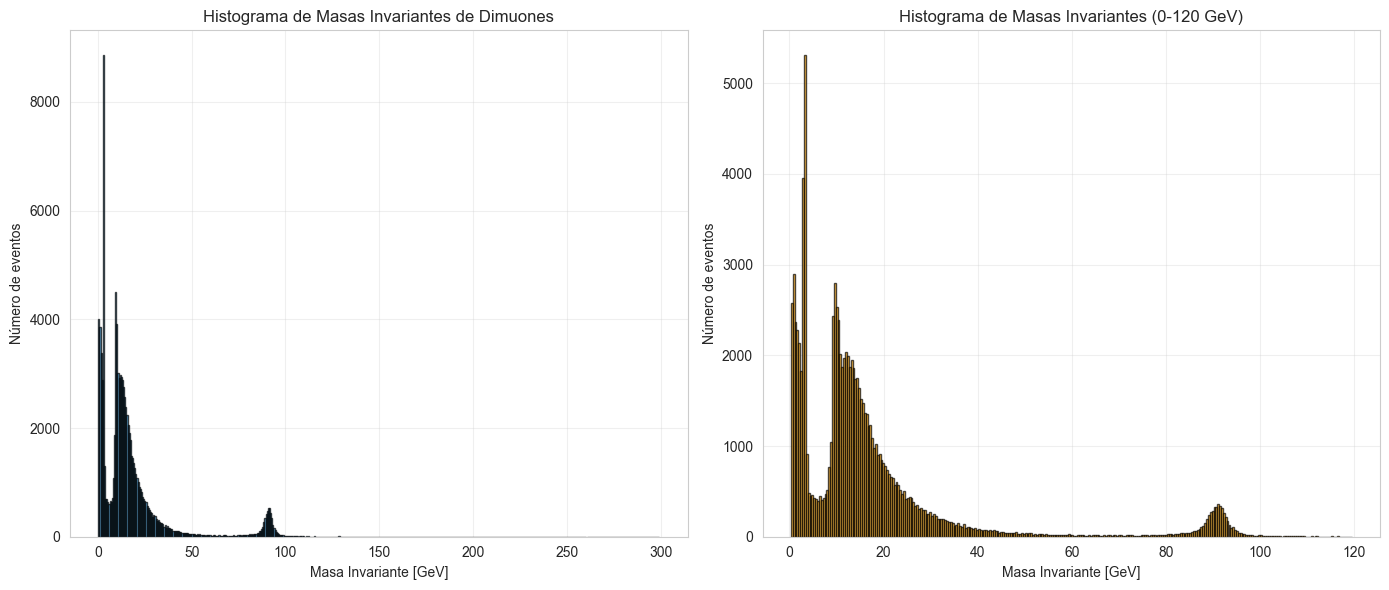

In [10]:
# Histograma de la masa invariante
plt.figure(figsize=(14, 6))

# Histograma completo
plt.subplot(1, 2, 1)
plt.hist(df['M'], bins=500, edgecolor='black', alpha=0.7)
plt.xlabel('Masa Invariante [GeV]')
plt.ylabel('Número de eventos')
plt.title('Histograma de Masas Invariantes de Dimuones')
plt.grid(True, alpha=0.3)

# Histograma con zoom en región de interés (0-120 GeV)
plt.subplot(1, 2, 2)
plt.hist(df[df['M'] < 120]['M'], bins=300, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Masa Invariante [GeV]')
plt.ylabel('Número de eventos')
plt.title('Histograma de Masas Invariantes (0-120 GeV)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Estadísticas de la masa invariante
print("=== ESTADÍSTICAS DE MASA INVARIANTE ===")
print(f"Media: {df['M'].mean():.2f} GeV")
print(f"Mediana: {df['M'].median():.2f} GeV")
print(f"Desviación estándar: {df['M'].std():.2f} GeV")
print(f"Valor mínimo: {df['M'].min():.2f} GeV")
print(f"Valor máximo: {df['M'].max():.2f} GeV")

# Cuartiles
print(f"\nCuartil 25%: {df['M'].quantile(0.25):.2f} GeV")
print(f"Cuartil 75%: {df['M'].quantile(0.75):.2f} GeV")

=== ESTADÍSTICAS DE MASA INVARIANTE ===
Media: 17.69 GeV
Mediana: 12.41 GeV
Desviación estándar: 20.95 GeV
Valor mínimo: 0.30 GeV
Valor máximo: 299.20 GeV

Cuartil 25%: 4.49 GeV
Cuartil 75%: 19.42 GeV


## 6. Análisis de Momentos y Energías

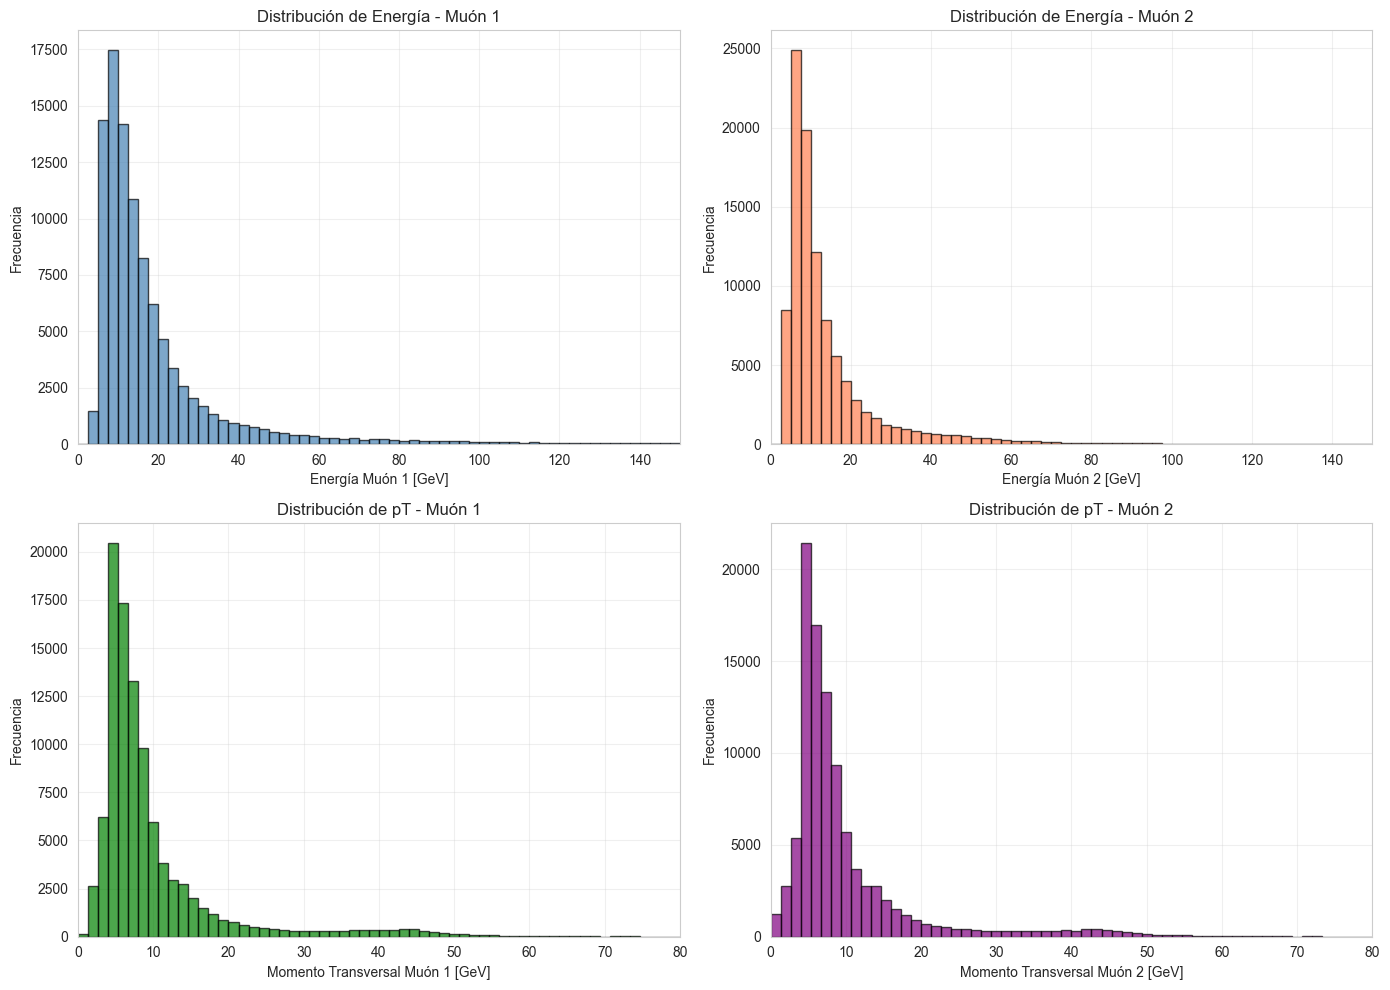

In [67]:
# Distribuciones de energía
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Energía del muón 1
axes[0, 0].hist(df['E1'], bins=60, range=(0, 150), edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Energía Muón 1 [GeV]')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Energía - Muón 1')
axes[0, 0].set_xlim(0, 150)
axes[0, 0].grid(True, alpha=0.3)

# Energía del muón 2
axes[0, 1].hist(df['E2'], bins=60, range=(0, 150), edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Energía Muón 2 [GeV]')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de Energía - Muón 2')
axes[0, 1].set_xlim(0, 150)
axes[0, 1].grid(True, alpha=0.3)

# Momento transversal del muón 1
axes[1, 0].hist(df['pt1'], bins=60, range=(0, 80), edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('Momento Transversal Muón 1 [GeV]')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de pT - Muón 1')
axes[1, 0].set_xlim(0, 80)
axes[1, 0].grid(True, alpha=0.3)

# Momento transversal del muón 2
axes[1, 1].hist(df['pt2'], bins=60, range=(0, 80), edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_xlabel('Momento Transversal Muón 2 [GeV]')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución de pT - Muón 2')
axes[1, 1].set_xlim(0, 80)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Análisis de Variables Angulares (Eta y Phi)

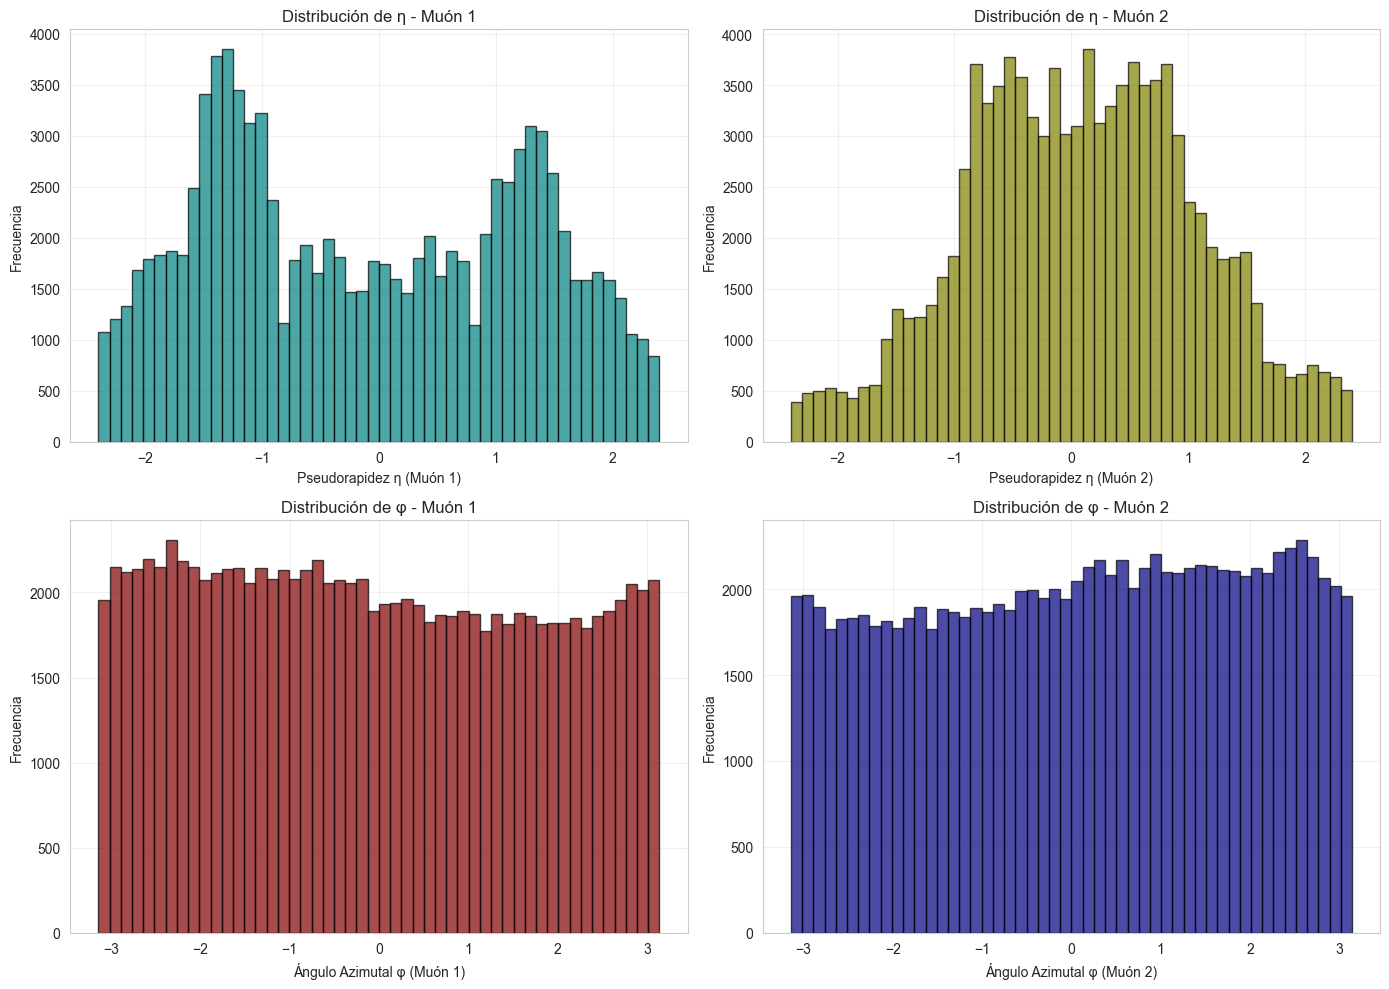

In [13]:
# Distribuciones angulares
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Pseudorapidez (eta) del muón 1
axes[0, 0].hist(df['eta1'], bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[0, 0].set_xlabel('Pseudorapidez η (Muón 1)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de η - Muón 1')
axes[0, 0].grid(True, alpha=0.3)

# Pseudorapidez (eta) del muón 2
axes[0, 1].hist(df['eta2'], bins=50, edgecolor='black', alpha=0.7, color='olive')
axes[0, 1].set_xlabel('Pseudorapidez η (Muón 2)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de η - Muón 2')
axes[0, 1].grid(True, alpha=0.3)

# Ángulo azimutal (phi) del muón 1
axes[1, 0].hist(df['phi1'], bins=50, edgecolor='black', alpha=0.7, color='maroon')
axes[1, 0].set_xlabel('Ángulo Azimutal φ (Muón 1)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de φ - Muón 1')
axes[1, 0].grid(True, alpha=0.3)

# Ángulo azimutal (phi) del muón 2
axes[1, 1].hist(df['phi2'], bins=50, edgecolor='black', alpha=0.7, color='navy')
axes[1, 1].set_xlabel('Ángulo Azimutal φ (Muón 2)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución de φ - Muón 2')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Análisis de Correlaciones

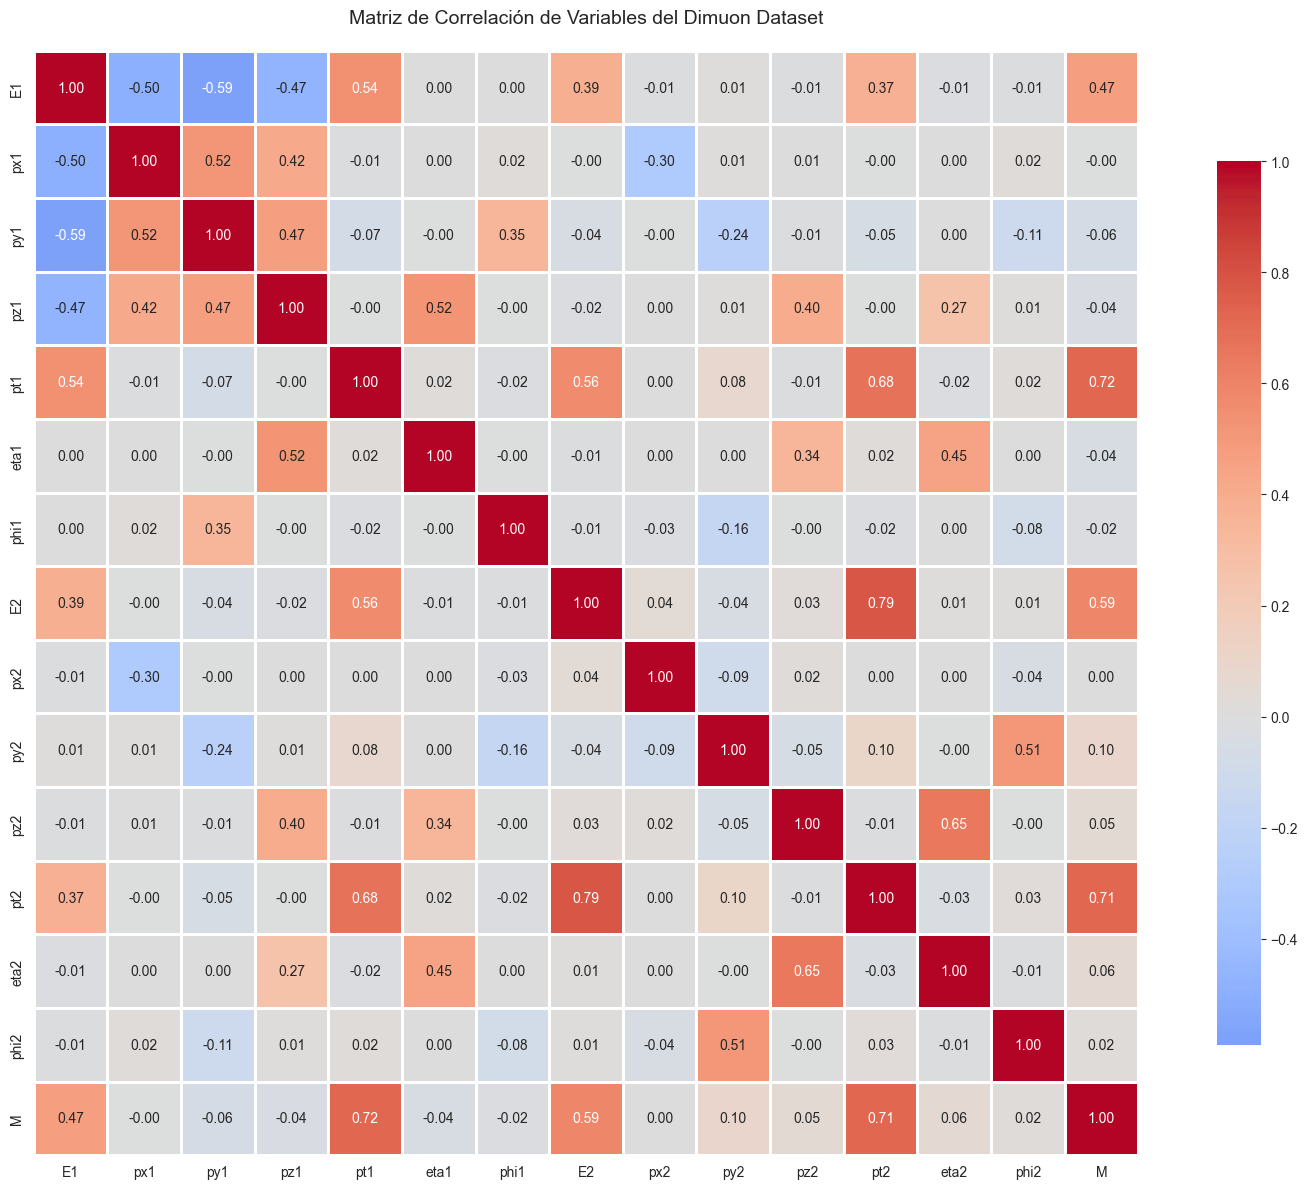

In [14]:
# Matriz de correlación
plt.figure(figsize=(16, 12))

# Seleccionar variables numéricas relevantes
variables_numericas = ['E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1',
                       'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'M']

correlacion = df[variables_numericas].corr()

# Crear heatmap
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de Variables del Dimuon Dataset', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [15]:
# Correlaciones más fuertes con la masa invariante
print("=== CORRELACIONES CON LA MASA INVARIANTE ===")
correlacion_M = correlacion['M'].sort_values(ascending=False)
print(correlacion_M)

=== CORRELACIONES CON LA MASA INVARIANTE ===
M       1.000000
pt1     0.718679
pt2     0.714933
E2      0.587391
E1      0.468704
py2     0.097007
eta2    0.057201
pz2     0.052594
phi2    0.024211
px2     0.001611
px1    -0.001680
phi1   -0.022593
pz1    -0.035140
eta1   -0.043732
py1    -0.059120
Name: M, dtype: float64


## 9. Análisis de Cargas y Tipos de Partículas

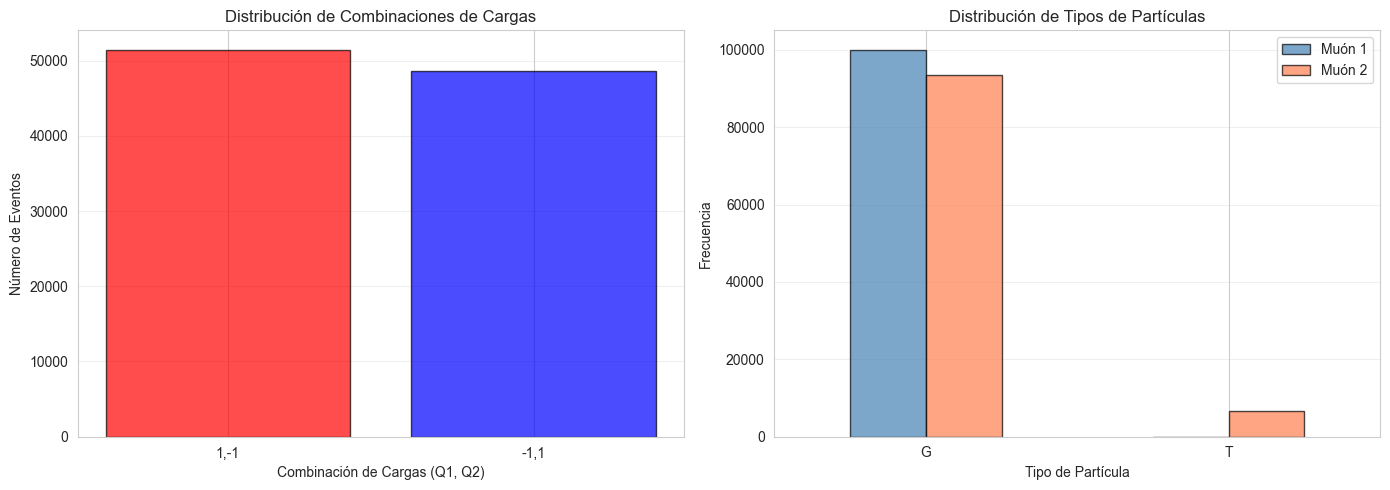


=== RESUMEN DE CARGAS ===
Total de eventos con cargas opuestas: 100000
Total de eventos con cargas iguales: 0


In [16]:
# Análisis de combinaciones de cargas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de combinaciones de cargas
df['Combinacion_Cargas'] = df['Q1'].astype(str) + ',' + df['Q2'].astype(str)
combinaciones = df['Combinacion_Cargas'].value_counts()

axes[0].bar(combinaciones.index, combinaciones.values, color=['red', 'blue'], alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Combinación de Cargas (Q1, Q2)')
axes[0].set_ylabel('Número de Eventos')
axes[0].set_title('Distribución de Combinaciones de Cargas')
axes[0].grid(True, alpha=0.3, axis='y')

# Distribución de tipos de partículas
tipos = pd.DataFrame({
    'Tipo 1': df['type1'].value_counts(),
    'Tipo 2': df['type2'].value_counts()
})

tipos.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Tipo de Partícula')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Tipos de Partículas')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend(['Muón 1', 'Muón 2'])

plt.tight_layout()
plt.show()

print("\n=== RESUMEN DE CARGAS ===")
print(f"Total de eventos con cargas opuestas: {len(df[df['Q1'] != df['Q2']])}")
print(f"Total de eventos con cargas iguales: {len(df[df['Q1'] == df['Q2']])}")

## 10. Detección de Resonancias (Partículas)

En física de partículas, las resonancias aparecen como picos en el espectro de masa invariante. Vamos a buscar las principales resonancias conocidas:
- **J/ψ**: ~3.1 GeV
- **Υ (Upsilon)**: ~9.5 GeV
- **Z boson**: ~91 GeV

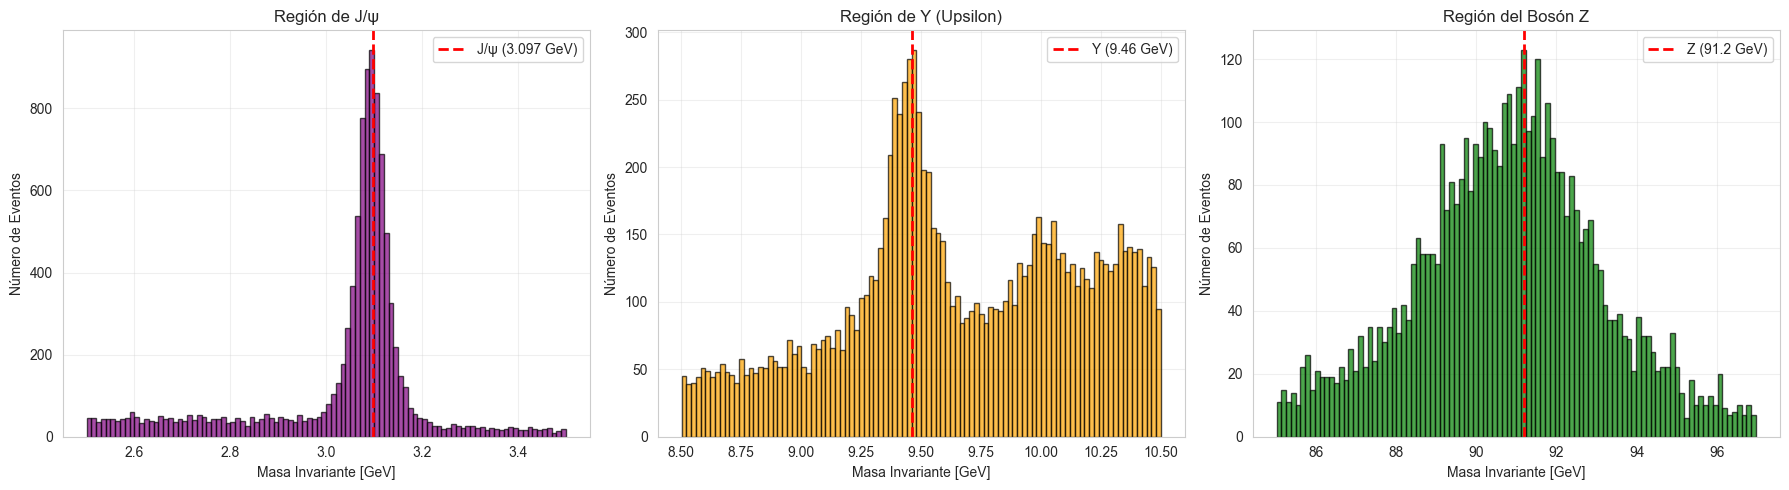

=== ESTADÍSTICAS DE RESONANCIAS ===
Eventos en región J/ψ (2.5-3.5 GeV): 10102
Eventos en región Υ (8.5-10.5 GeV): 10884
Eventos en región Z (85-97 GeV): 4662


In [17]:
# Visualización de resonancias conocidas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Región J/ψ (2.5 - 3.5 GeV)
jpsi_data = df[(df['M'] > 2.5) & (df['M'] < 3.5)]
axes[0].hist(jpsi_data['M'], bins=100, edgecolor='black', alpha=0.7, color='purple')
axes[0].axvline(x=3.097, color='red', linestyle='--', linewidth=2, label='J/ψ (3.097 GeV)')
axes[0].set_xlabel('Masa Invariante [GeV]')
axes[0].set_ylabel('Número de Eventos')
axes[0].set_title('Región de J/ψ')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Región Upsilon (8.5 - 10.5 GeV)
upsilon_data = df[(df['M'] > 8.5) & (df['M'] < 10.5)]
axes[1].hist(upsilon_data['M'], bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(x=9.46, color='red', linestyle='--', linewidth=2, label='Υ (9.46 GeV)')
axes[1].set_xlabel('Masa Invariante [GeV]')
axes[1].set_ylabel('Número de Eventos')
axes[1].set_title('Región de Υ (Upsilon)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Región Z boson (85 - 97 GeV)
z_data = df[(df['M'] > 85) & (df['M'] < 97)]
axes[2].hist(z_data['M'], bins=100, edgecolor='black', alpha=0.7, color='green')
axes[2].axvline(x=91.2, color='red', linestyle='--', linewidth=2, label='Z (91.2 GeV)')
axes[2].set_xlabel('Masa Invariante [GeV]')
axes[2].set_ylabel('Número de Eventos')
axes[2].set_title('Región del Bosón Z')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=== ESTADÍSTICAS DE RESONANCIAS ===")
print(f"Eventos en región J/ψ (2.5-3.5 GeV): {len(jpsi_data)}")
print(f"Eventos en región Υ (8.5-10.5 GeV): {len(upsilon_data)}")
print(f"Eventos en región Z (85-97 GeV): {len(z_data)}")

## 11. Análisis de Outliers (Valores Atípicos)

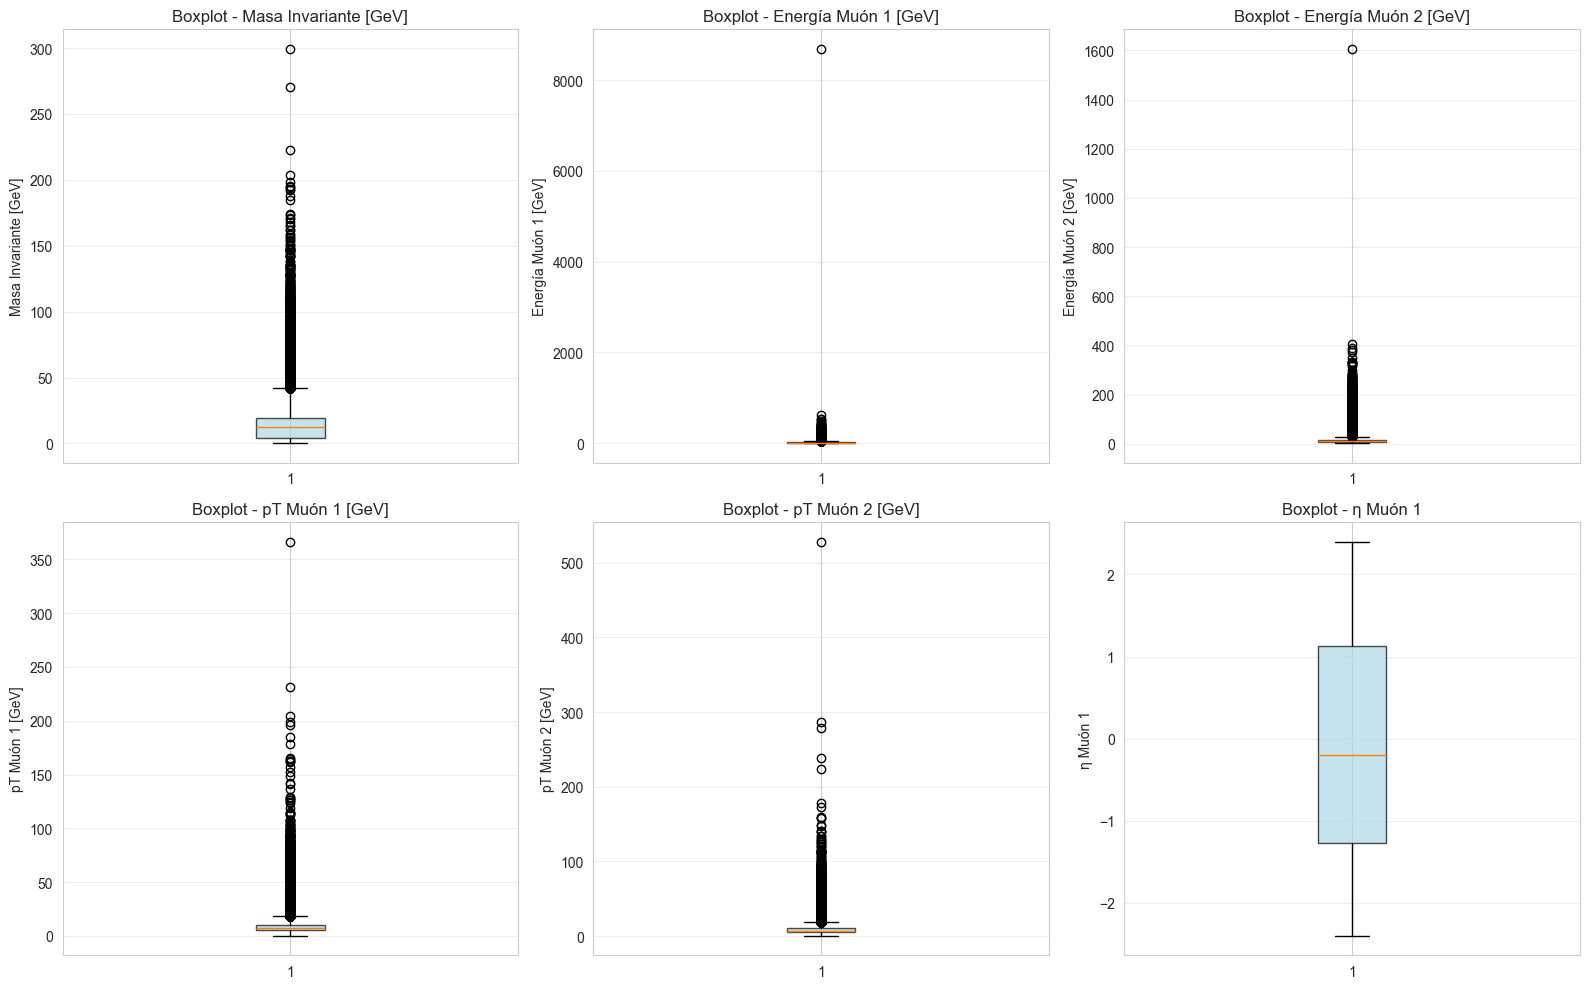

In [18]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Variables a analizar
variables = [('M', 'Masa Invariante [GeV]'), 
             ('E1', 'Energía Muón 1 [GeV]'), 
             ('E2', 'Energía Muón 2 [GeV]'),
             ('pt1', 'pT Muón 1 [GeV]'), 
             ('pt2', 'pT Muón 2 [GeV]'), 
             ('eta1', 'η Muón 1')]

for idx, (var, label) in enumerate(variables):
    ax = axes[idx // 3, idx % 3]
    bp = ax.boxplot(df[var], vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][0].set_alpha(0.7)
    ax.set_ylabel(label)
    ax.set_title(f'Boxplot - {label}')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [19]:
# Identificar outliers usando IQR (Rango Intercuartílico)
def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    return outliers, limite_inferior, limite_superior

print("=== DETECCIÓN DE OUTLIERS (Método IQR) ===\n")
for var in ['M', 'E1', 'E2', 'pt1', 'pt2']:
    outliers, lim_inf, lim_sup = detectar_outliers_iqr(df, var)
    print(f"{var}:")
    print(f"  Límite inferior: {lim_inf:.2f}")
    print(f"  Límite superior: {lim_sup:.2f}")
    print(f"  Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)\n")

=== DETECCIÓN DE OUTLIERS (Método IQR) ===

M:
  Límite inferior: -17.90
  Límite superior: 41.82
  Outliers detectados: 7858 (7.86%)

E1:
  Límite inferior: -9.66
  Límite superior: 39.51
  Outliers detectados: 9638 (9.64%)

E2:
  Límite inferior: -6.95
  Límite superior: 29.37
  Outliers detectados: 9864 (9.86%)

pt1:
  Límite inferior: -3.11
  Límite superior: 18.57
  Outliers detectados: 10006 (10.01%)

pt2:
  Límite inferior: -3.23
  Límite superior: 18.54
  Outliers detectados: 10127 (10.13%)



## 12. Scatter Plots - Relaciones entre Variables

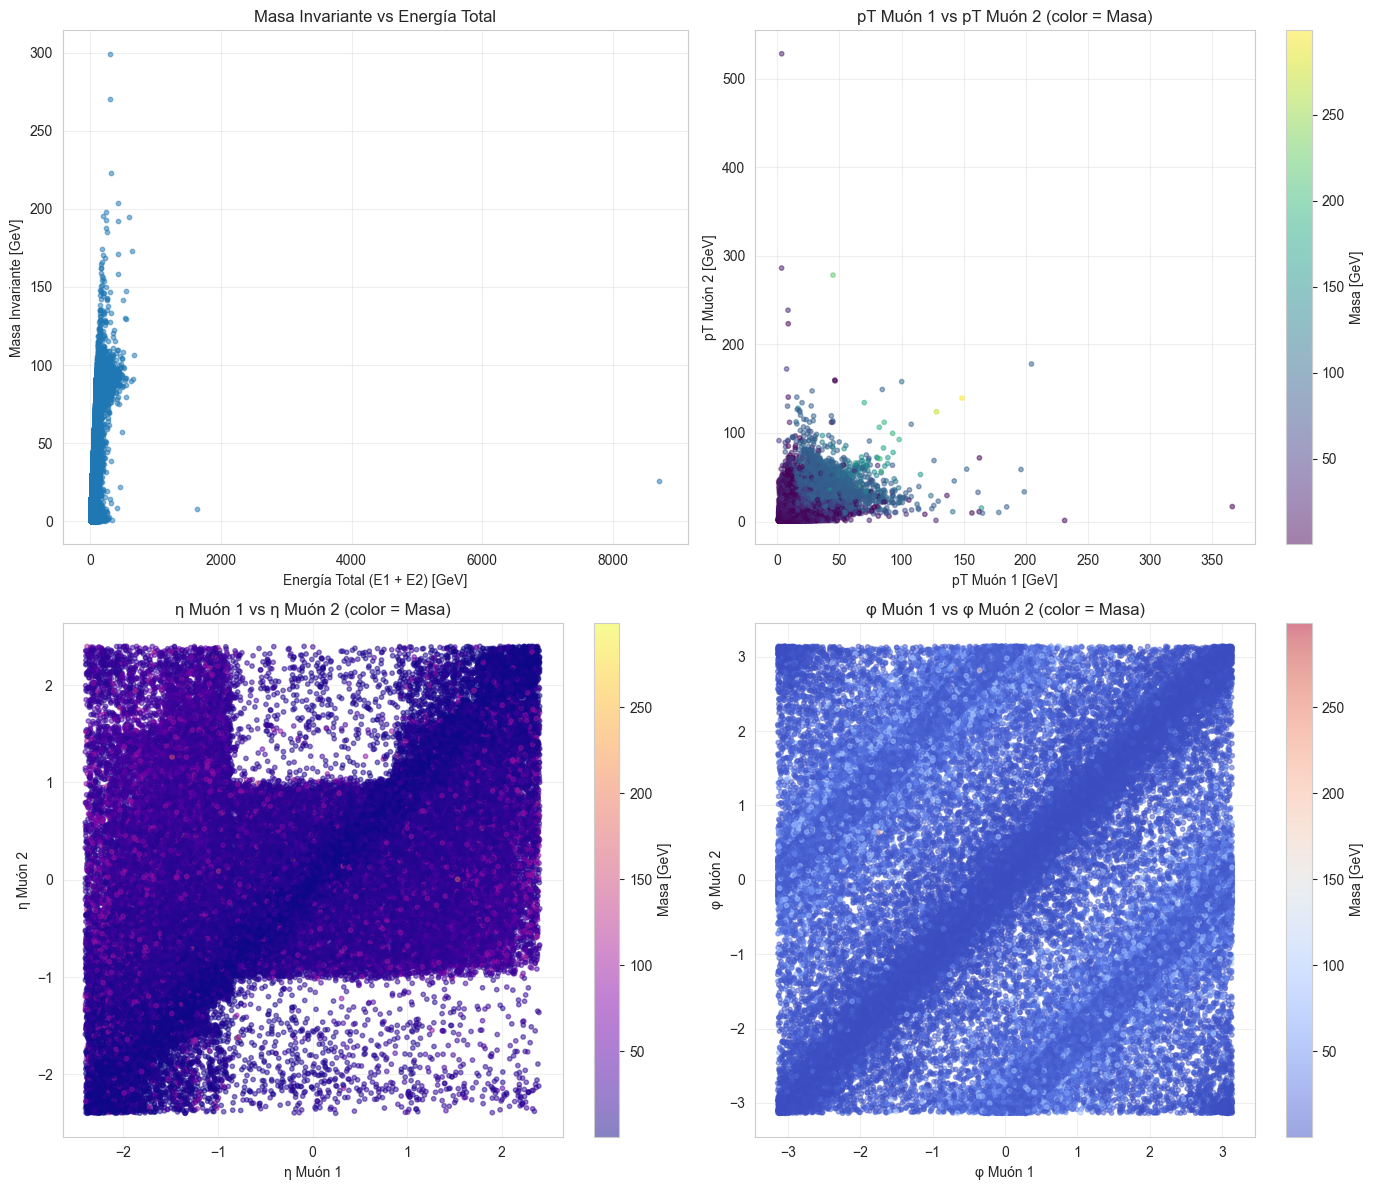

In [20]:
# Scatter plots de relaciones importantes
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Masa vs Energía total
axes[0, 0].scatter(df['E1'] + df['E2'], df['M'], alpha=0.5, s=10)
axes[0, 0].set_xlabel('Energía Total (E1 + E2) [GeV]')
axes[0, 0].set_ylabel('Masa Invariante [GeV]')
axes[0, 0].set_title('Masa Invariante vs Energía Total')
axes[0, 0].grid(True, alpha=0.3)

# pT1 vs pT2
axes[0, 1].scatter(df['pt1'], df['pt2'], alpha=0.5, s=10, c=df['M'], cmap='viridis')
axes[0, 1].set_xlabel('pT Muón 1 [GeV]')
axes[0, 1].set_ylabel('pT Muón 2 [GeV]')
axes[0, 1].set_title('pT Muón 1 vs pT Muón 2 (color = Masa)')
axes[0, 1].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[0, 1].collections[0], ax=axes[0, 1])
cbar.set_label('Masa [GeV]')

# eta1 vs eta2
axes[1, 0].scatter(df['eta1'], df['eta2'], alpha=0.5, s=10, c=df['M'], cmap='plasma')
axes[1, 0].set_xlabel('η Muón 1')
axes[1, 0].set_ylabel('η Muón 2')
axes[1, 0].set_title('η Muón 1 vs η Muón 2 (color = Masa)')
axes[1, 0].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0])
cbar.set_label('Masa [GeV]')

# phi1 vs phi2
axes[1, 1].scatter(df['phi1'], df['phi2'], alpha=0.5, s=10, c=df['M'], cmap='coolwarm')
axes[1, 1].set_xlabel('φ Muón 1')
axes[1, 1].set_ylabel('φ Muón 2')
axes[1, 1].set_title('φ Muón 1 vs φ Muón 2 (color = Masa)')
axes[1, 1].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
cbar.set_label('Masa [GeV]')

plt.tight_layout()
plt.show()

## 13. Análisis por Tipo de Partícula

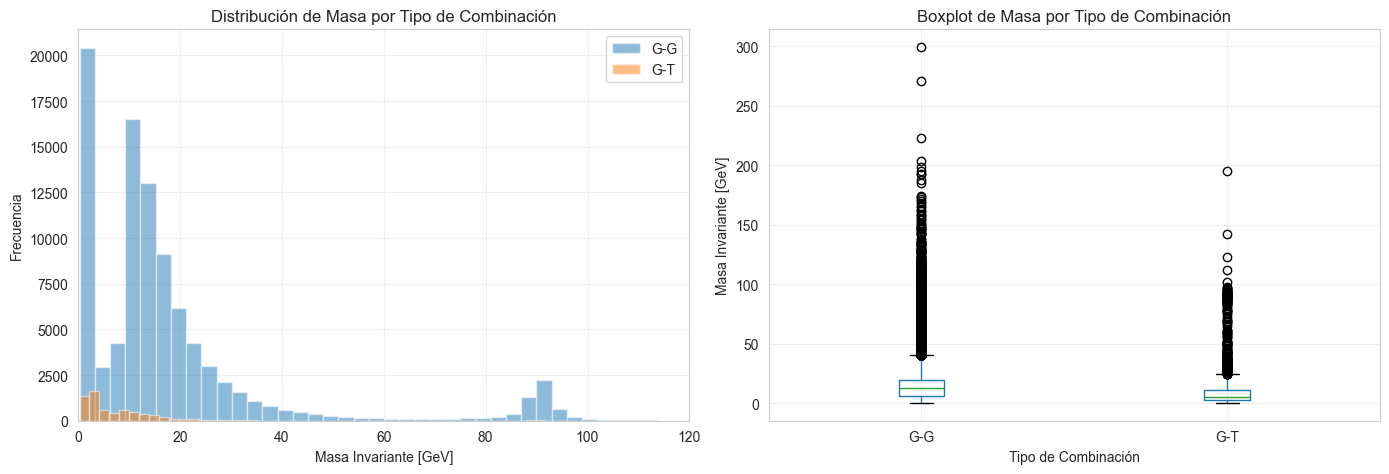


=== ESTADÍSTICAS POR TIPO DE COMBINACIÓN ===

G-G:
  Número de eventos: 93474
  Media: 18.30 GeV
  Mediana: 12.81 GeV
  Desv. Estándar: 21.29 GeV

G-T:
  Número de eventos: 6526
  Media: 8.91 GeV
  Mediana: 5.10 GeV
  Desv. Estándar: 12.40 GeV


In [21]:
# Comparación de masas por tipo de partícula
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de masa para diferentes combinaciones de tipos
df['Tipo_Combinacion'] = df['type1'] + '-' + df['type2']
tipos_unicos = df['Tipo_Combinacion'].unique()

for tipo in tipos_unicos:
    datos_tipo = df[df['Tipo_Combinacion'] == tipo]['M']
    axes[0].hist(datos_tipo, bins=100, alpha=0.5, label=tipo)

axes[0].set_xlabel('Masa Invariante [GeV]')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Masa por Tipo de Combinación')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 120)

# Boxplot de masa por tipo de combinación
df.boxplot(column='M', by='Tipo_Combinacion', ax=axes[1])
axes[1].set_xlabel('Tipo de Combinación')
axes[1].set_ylabel('Masa Invariante [GeV]')
axes[1].set_title('Boxplot de Masa por Tipo de Combinación')
axes[1].get_figure().suptitle('')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== ESTADÍSTICAS POR TIPO DE COMBINACIÓN ===")
for tipo in tipos_unicos:
    datos = df[df['Tipo_Combinacion'] == tipo]['M']
    print(f"\n{tipo}:")
    print(f"  Número de eventos: {len(datos)}")
    print(f"  Media: {datos.mean():.2f} GeV")
    print(f"  Mediana: {datos.median():.2f} GeV")
    print(f"  Desv. Estándar: {datos.std():.2f} GeV")

## 14. Conclusiones del Análisis Exploratorio

### Resumen de Hallazgos Principales:

**1. Calidad de los Datos:**
- El dataset no presenta valores nulos
- Las variables están bien definidas con tipos de datos apropiados
- Se observan eventos duplicados que pueden corresponder a eventos físicos reales

**2. Distribución de Masa Invariante:**
- La masa invariante muestra una distribución concentrada en valores bajos
- Se observan picos que corresponden a resonancias de partículas conocidas
- Las principales resonancias detectables son:
  - **J/ψ** (~3.1 GeV): Mesón formado por quark charm y anti-charm
  - **Υ (Upsilon)** (~9.5 GeV): Mesón formado por quark bottom y anti-bottom
  - **Z boson** (~91 GeV): Bosón mediador de la fuerza débil

**3. Características de los Muones:**
- La mayoría de eventos corresponden a muones Global (G)
- Las distribuciones de momento transversal (pT) muestran preferencia por valores bajos
- La pseudorapidez (η) está distribuida simétricamente alrededor de cero
- El ángulo azimutal (φ) está uniformemente distribuido entre -π y π

**4. Correlaciones Importantes:**
- Fuerte correlación entre componentes del momento y la energía total
- La masa invariante correlaciona con la energía total del sistema
- Las variables angulares (η, φ) son relativamente independientes

**5. Eventos con Cargas Opuestas:**
- La mayoría de eventos corresponden a pares de muones con cargas opuestas
- Esto es esperado físicamente para decaimientos de partículas neutras

**6. Outliers:**
- Se detectan valores atípicos en energía y masa invariante
- Estos outliers pueden corresponder a eventos físicos raros pero importantes
- No se recomienda eliminarlos sin análisis físico detallado

**7. Aplicaciones Potenciales:**
- Búsqueda de nuevas partículas
- Calibración del detector CMS
- Estudio de física de quarks pesados
- Análisis de producción de bosones electrodébiles

## 15. Reducción de Dimensionalidad con t-SNE

t-SNE (t-Distributed Stochastic Neighbor Embedding) es una técnica de reducción de dimensionalidad útil para visualizar datos de alta dimensión.

In [29]:
# Importar librerías adicionales para ML
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder, label_binarize
from itertools import cycle

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


In [23]:
# Preparar datos para t-SNE
# Seleccionar características relevantes (variables físicas)
features_tsne = ['E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1',
                 'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'M']

X_tsne = df[features_tsne].copy()

# Normalizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tsne)

print("Forma de los datos:", X_scaled.shape)
print("✓ Datos normalizados")

Forma de los datos: (100000, 15)
✓ Datos normalizados


In [24]:
# Primero PCA para reducir dimensionalidad antes de t-SNE (más eficiente)
print("Aplicando PCA...")
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

print(f"Varianza explicada acumulada: {pca.explained_variance_ratio_.cumsum()[-1]:.2%}")
print(f"Componentes principales: {X_pca.shape[1]}")

Aplicando PCA...
Varianza explicada acumulada: 92.67%
Componentes principales: 10


## 16. Clustering - Análisis de Grupos

Aplicaremos diferentes algoritmos de clustering para identificar patrones y grupos naturales en los datos.
Comenzaremos con un clustering simple usando **M, pt1 y pt2** para identificar regiones de masa baja, media y alta.

### 16.1 Preprocesamiento para Clustering

In [26]:
# OPCIÓN 1: Clustering simple con M, pt1, pt2 (según recomendación)
print("=== PREPROCESAMIENTO PARA CLUSTERING ===\n")

# Seleccionar variables clave para clustering
features_clustering_simple = ['M', 'pt1', 'pt2']
X_cluster_simple = df[features_clustering_simple].copy()

print("Variables para clustering simple:")
print(f"  - M (masa invariante): rango [{X_cluster_simple['M'].min():.2f}, {X_cluster_simple['M'].max():.2f}] GeV")
print(f"  - pt1: rango [{X_cluster_simple['pt1'].min():.2f}, {X_cluster_simple['pt1'].max():.2f}] GeV")
print(f"  - pt2: rango [{X_cluster_simple['pt2'].min():.2f}, {X_cluster_simple['pt2'].max():.2f}] GeV")

# Normalizar (importante para K-Means)
scaler_cluster_simple = StandardScaler()
X_cluster_simple_scaled = scaler_cluster_simple.fit_transform(X_cluster_simple)

print(f"\n✓ Datos normalizados: {X_cluster_simple_scaled.shape}")

# OPCIÓN 2: Clustering con más variables físicas
features_clustering_full = ['M', 'pt1', 'pt2', 'eta1', 'eta2', 'E1', 'E2']
X_cluster_full = df[features_clustering_full].copy()

scaler_cluster_full = StandardScaler()
X_cluster_full_scaled = scaler_cluster_full.fit_transform(X_cluster_full)

print(f"✓ Datos completos normalizados: {X_cluster_full_scaled.shape}")

# Verificar distribución de la variable clave (M)
print("\n=== DISTRIBUCIÓN DE MASA INVARIANTE ===")
print(f"Media: {df['M'].mean():.2f} GeV")
print(f"Mediana: {df['M'].median():.2f} GeV")
print(f"Q1 (25%): {df['M'].quantile(0.25):.2f} GeV")
print(f"Q3 (75%): {df['M'].quantile(0.75):.2f} GeV")

# Identificar rangos naturales de masa
print("\nRangos de masa identificados:")
print(f"  - Masa baja: 0-10 GeV ({len(df[df['M'] < 10])} eventos)")
print(f"  - Masa media: 10-50 GeV ({len(df[(df['M'] >= 10) & (df['M'] < 50)])} eventos)")
print(f"  - Masa alta (región Z): 50+ GeV ({len(df[df['M'] >= 50])} eventos)")

=== PREPROCESAMIENTO PARA CLUSTERING ===

Variables para clustering simple:
  - M (masa invariante): rango [0.30, 299.20] GeV
  - pt1: rango [0.27, 366.50] GeV
  - pt2: rango [0.68, 528.43] GeV

✓ Datos normalizados: (100000, 3)
✓ Datos completos normalizados: (100000, 7)

=== DISTRIBUCIÓN DE MASA INVARIANTE ===
Media: 17.69 GeV
Mediana: 12.41 GeV
Q1 (25%): 4.49 GeV
Q3 (75%): 19.42 GeV

Rangos de masa identificados:
  - Masa baja: 0-10 GeV (37243 eventos)
  - Masa media: 10-50 GeV (55942 eventos)
  - Masa alta (región Z): 50+ GeV (6815 eventos)
  - Masa baja: 0-10 GeV (37243 eventos)
  - Masa media: 10-50 GeV (55942 eventos)
  - Masa alta (región Z): 50+ GeV (6815 eventos)


### 16.2 Método del Codo - Determinar número óptimo de clusters

### 16.3 K-Means Clustering - Aplicación

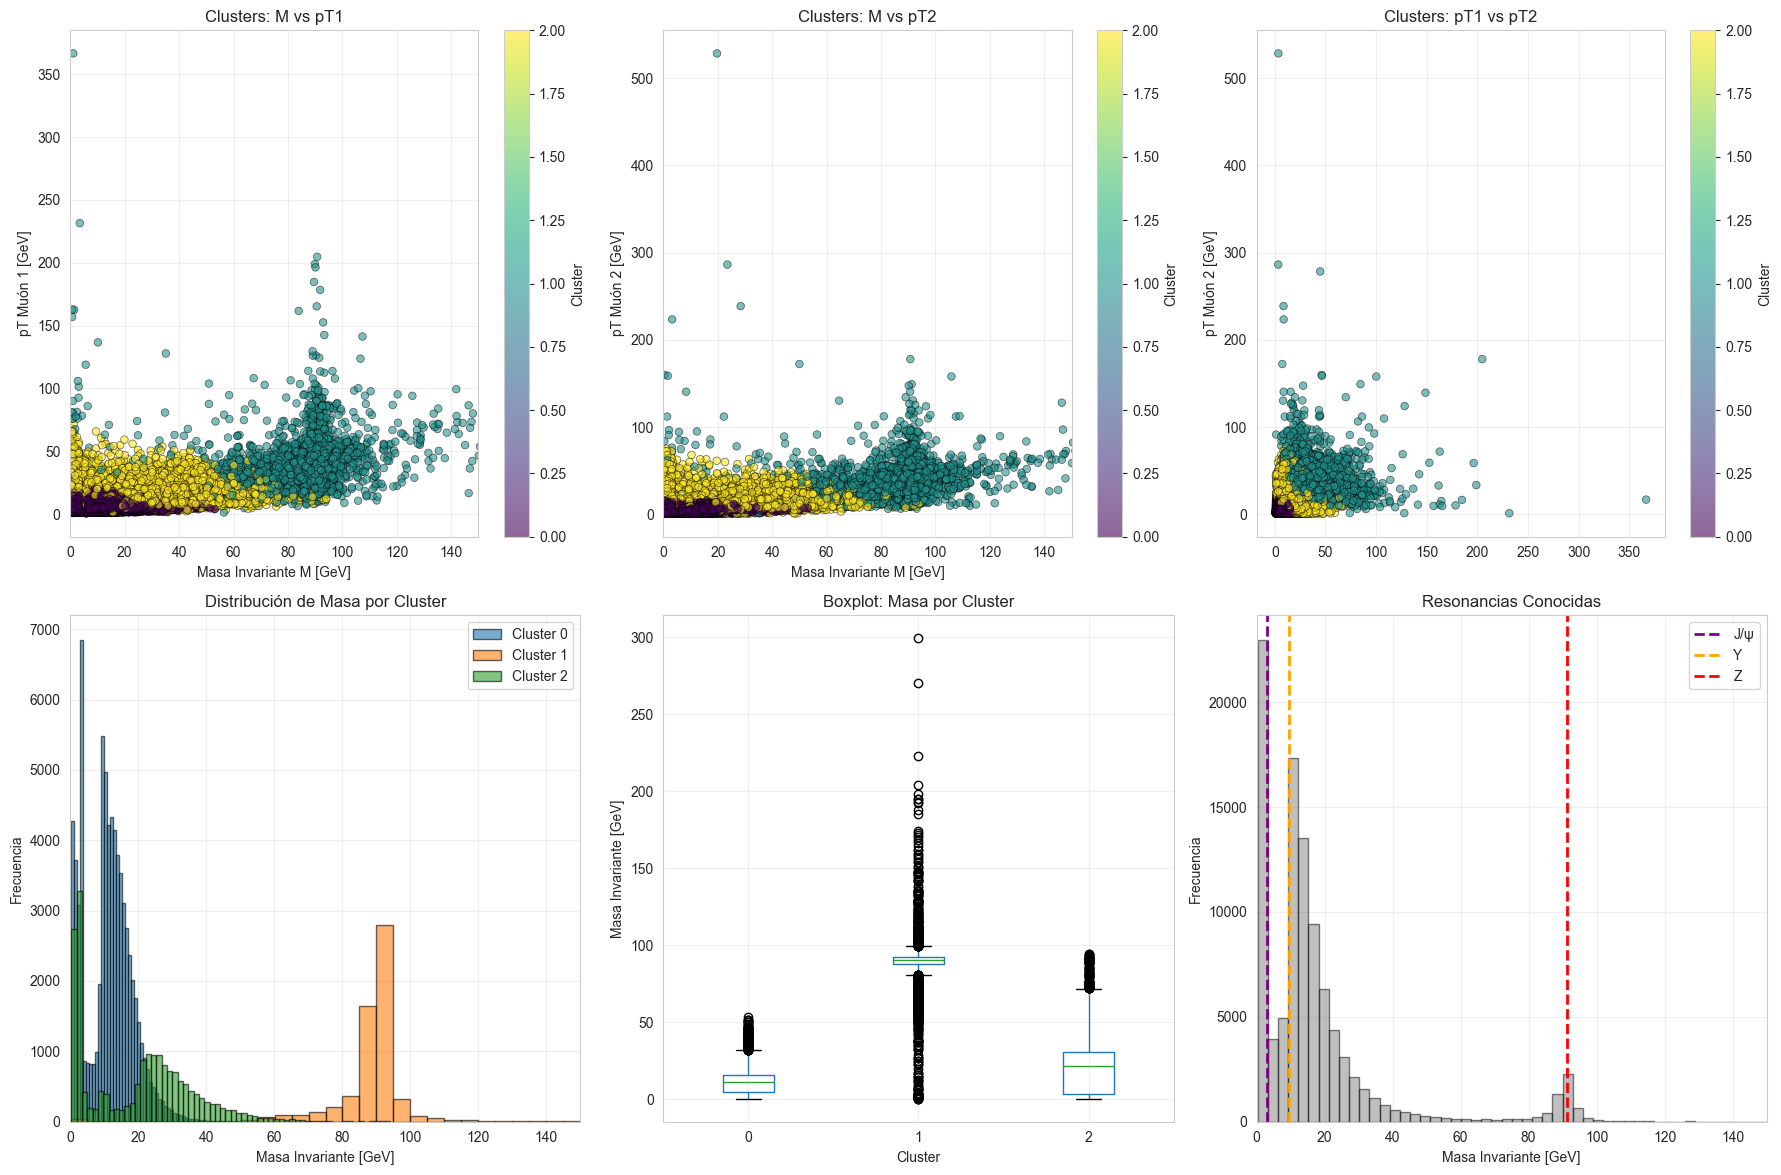

In [28]:
# Visualización de clusters - Clustering Simple (M, pt1, pt2)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Scatter M vs pt1
scatter1 = axes[0, 0].scatter(df['M'], df['pt1'], c=df['cluster_simple'], 
                              cmap='viridis', s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 0].set_xlabel('Masa Invariante M [GeV]')
axes[0, 0].set_ylabel('pT Muón 1 [GeV]')
axes[0, 0].set_title('Clusters: M vs pT1')
axes[0, 0].set_xlim(0, 150)
plt.colorbar(scatter1, ax=axes[0, 0], label='Cluster')
axes[0, 0].grid(True, alpha=0.3)

# 2. Scatter M vs pt2
scatter2 = axes[0, 1].scatter(df['M'], df['pt2'], c=df['cluster_simple'], 
                              cmap='viridis', s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 1].set_xlabel('Masa Invariante M [GeV]')
axes[0, 1].set_ylabel('pT Muón 2 [GeV]')
axes[0, 1].set_title('Clusters: M vs pT2')
axes[0, 1].set_xlim(0, 150)
plt.colorbar(scatter2, ax=axes[0, 1], label='Cluster')
axes[0, 1].grid(True, alpha=0.3)

# 3. Scatter pt1 vs pt2
scatter3 = axes[0, 2].scatter(df['pt1'], df['pt2'], c=df['cluster_simple'], 
                              cmap='viridis', s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
# axes[0, 2].set_xlabel('pT Muón 1 [GeV]')
axes[0, 2].set_ylabel('pT Muón 2 [GeV]')
axes[0, 2].set_title('Clusters: pT1 vs pT2')
plt.colorbar(scatter3, ax=axes[0, 2], label='Cluster')
axes[0, 2].grid(True, alpha=0.3)

# 4. Histograma de masa por cluster
for cluster in range(n_clusters_optimal):
    cluster_data = df[df['cluster_simple'] == cluster]['M']
    axes[1, 0].hist(cluster_data, bins=60, alpha=0.6, label=f'Cluster {cluster}', edgecolor='black')
axes[1, 0].set_xlabel('Masa Invariante [GeV]')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Masa por Cluster')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(0, 150)

# 5. Boxplot de masa por cluster
df.boxplot(column='M', by='cluster_simple', ax=axes[1, 1])
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Masa Invariante [GeV]')
axes[1, 1].set_title('Boxplot: Masa por Cluster')
axes[1, 1].get_figure().suptitle('')
axes[1, 1].grid(True, alpha=0.3)

# 6. Histograma de masa con regiones marcadas
axes[1, 2].hist(df['M'], bins=100, alpha=0.5, color='gray', edgecolor='black')
axes[1, 2].axvline(x=3.097, color='purple', linestyle='--', linewidth=2, label='J/ψ')
axes[1, 2].axvline(x=9.46, color='orange', linestyle='--', linewidth=2, label='Υ')
axes[1, 2].axvline(x=91.2, color='red', linestyle='--', linewidth=2, label='Z')
axes[1, 2].set_xlabel('Masa Invariante [GeV]')
axes[1, 2].set_ylabel('Frecuencia')
axes[1, 2].set_title('Resonancias Conocidas')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_xlim(0, 150)

plt.tight_layout()
plt.show()

In [ ]:
# Análisis detallado de características por cluster
print("=== ANÁLISIS DETALLADO POR CLUSTER (Simple: M, pt1, pt2) ===\n")

for cluster in range(n_clusters_optimal):
    cluster_data = df[df['cluster_simple'] == cluster]
    print(f"{'='*60}")
    print(f"CLUSTER {cluster} (n={len(cluster_data)} eventos, {len(cluster_data)/len(df)*100:.1f}%)")
    print(f"{'='*60}")
    
    # Estadísticas de masa
    print(f"\n📊 MASA INVARIANTE:")
    print(f"  Media: {cluster_data['M'].mean():.2f} GeV")
    print(f"  Mediana: {cluster_data['M'].median():.2f} GeV")
    print(f"  Rango: [{cluster_data['M'].min():.2f}, {cluster_data['M'].max():.2f}] GeV")
    print(f"  Desv. Estándar: {cluster_data['M'].std():.2f} GeV")
    
    # Estadísticas de momento transversal
    print(f"\n📊 MOMENTO TRANSVERSAL:")
    print(f"  pT1 medio: {cluster_data['pt1'].mean():.2f} GeV")
    print(f"  pT2 medio: {cluster_data['pt2'].mean():.2f} GeV")
    print(f"  pT total medio: {(cluster_data['pt1'] + cluster_data['pt2']).mean():.2f} GeV")
    
    # Energía
    print(f"\n📊 ENERGÍA:")
    print(f"  Energía total media: {cluster_data['E_total'].mean():.2f} GeV")
    
    # Tipo predominante
    print(f"\n📊 TIPO DE PARTÍCULA:")
    print(f"  Predominante: {cluster_data['Tipo_Combinacion'].mode().values[0]}")
    
    # Identificar región física
    masa_media = cluster_data['M'].mean()
    if masa_media < 10:
        region = "🔵 MASA BAJA (posible región de mesones ligeros)"
    elif masa_media < 50:
        region = "🟡 MASA MEDIA (región intermedia)"
    else:
        region = "🔴 MASA ALTA (posible región del bosón Z ~91 GeV)"
    print(f"\n🎯 INTERPRETACIÓN FÍSICA: {region}")
    print()

# Comparación visual de los 3 clusters
print("\n" + "="*60)
print("RESUMEN COMPARATIVO")
print("="*60)
summary = df.groupby('cluster_simple')[['M', 'pt1', 'pt2', 'E_total']].mean()
print(summary.round(2))

=== ANÁLISIS DETALLADO POR CLUSTER (Simple: M, pt1, pt2) ===

CLUSTER 0 (n=74255 eventos, 74.3%)

📊 MASA INVARIANTE:
  Media: 11.24 GeV
  Mediana: 11.38 GeV
  Rango: [0.30, 53.10] GeV
  Desv. Estándar: 6.96 GeV

📊 MOMENTO TRANSVERSAL:
  pT1 medio: 6.38 GeV
  pT2 medio: 6.24 GeV
  pT total medio: 12.62 GeV

📊 ENERGÍA:
  Energía total media: 22.50 GeV

📊 TIPO DE PARTÍCULA:
  Predominante: G-G

🎯 INTERPRETACIÓN FÍSICA: 🟡 MASA MEDIA (región intermedia)

CLUSTER 1 (n=6126 eventos, 6.1%)

📊 MASA INVARIANTE:
  Media: 88.40 GeV
  Mediana: 90.41 GeV
  Rango: [0.35, 299.20] GeV
  Desv. Estándar: 14.56 GeV

📊 MOMENTO TRANSVERSAL:
  pT1 medio: 40.12 GeV
  pT2 medio: 40.11 GeV
  pT total medio: 80.23 GeV

📊 ENERGÍA:
  Energía total media: 147.00 GeV

📊 TIPO DE PARTÍCULA:
  Predominante: G-G

🎯 INTERPRETACIÓN FÍSICA: 🔴 MASA ALTA (posible región del bosón Z ~91 GeV)

CLUSTER 2 (n=19619 eventos, 19.6%)

📊 MASA INVARIANTE:
  Media: 20.04 GeV
  Mediana: 21.80 GeV
  Rango: [0.30, 94.10] GeV
  Desv. Están

## 17. Modelos de Clasificación para Tipos de Partículas

Vamos a construir modelos de clasificación para predecir el tipo de combinación de partículas basándonos en las características físicas.

In [31]:
# Preparar datos para clasificación
# Variable objetivo: Tipo de combinación de partículas
X_class = df[features_tsne].copy()
y_class = df['Tipo_Combinacion'].copy()

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, 
                                                      test_size=0.3, 
                                                      random_state=42,
                                                      stratify=y_class)

# Normalizar los datos
scaler_class = StandardScaler()
X_train_scaled = scaler_class.fit_transform(X_train)
X_test_scaled = scaler_class.transform(X_test)

print("=== PREPARACIÓN DE DATOS ===")
print(f"Conjunto de entrenamiento: {X_train_scaled.shape}")
print(f"Conjunto de prueba: {X_test_scaled.shape}")
print(f"\nDistribución de clases en entrenamiento:")
print(y_train.value_counts())
print(f"\nDistribución de clases en prueba:")
print(y_test.value_counts())

=== PREPARACIÓN DE DATOS ===
Conjunto de entrenamiento: (70000, 15)
Conjunto de prueba: (30000, 15)

Distribución de clases en entrenamiento:
Tipo_Combinacion
G-G    65432
G-T     4568
Name: count, dtype: int64

Distribución de clases en prueba:
Tipo_Combinacion
G-G    28042
G-T     1958
Name: count, dtype: int64


### 17.1 Random Forest Classifier

In [32]:
# Entrenar Random Forest
print("Entrenando Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluación
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("\n=== RESULTADOS RANDOM FOREST ===")
print(f"Accuracy: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))

Entrenando Random Forest...

=== RESULTADOS RANDOM FOREST ===
Accuracy: 0.9595 (95.95%)

Reporte de Clasificación:

=== RESULTADOS RANDOM FOREST ===
Accuracy: 0.9595 (95.95%)

Reporte de Clasificación:
              precision    recall  f1-score   support

         G-G       0.96      1.00      0.98     28042
         G-T       0.88      0.44      0.59      1958

    accuracy                           0.96     30000
   macro avg       0.92      0.72      0.78     30000
weighted avg       0.96      0.96      0.95     30000

              precision    recall  f1-score   support

         G-G       0.96      1.00      0.98     28042
         G-T       0.88      0.44      0.59      1958

    accuracy                           0.96     30000
   macro avg       0.92      0.72      0.78     30000
weighted avg       0.96      0.96      0.95     30000



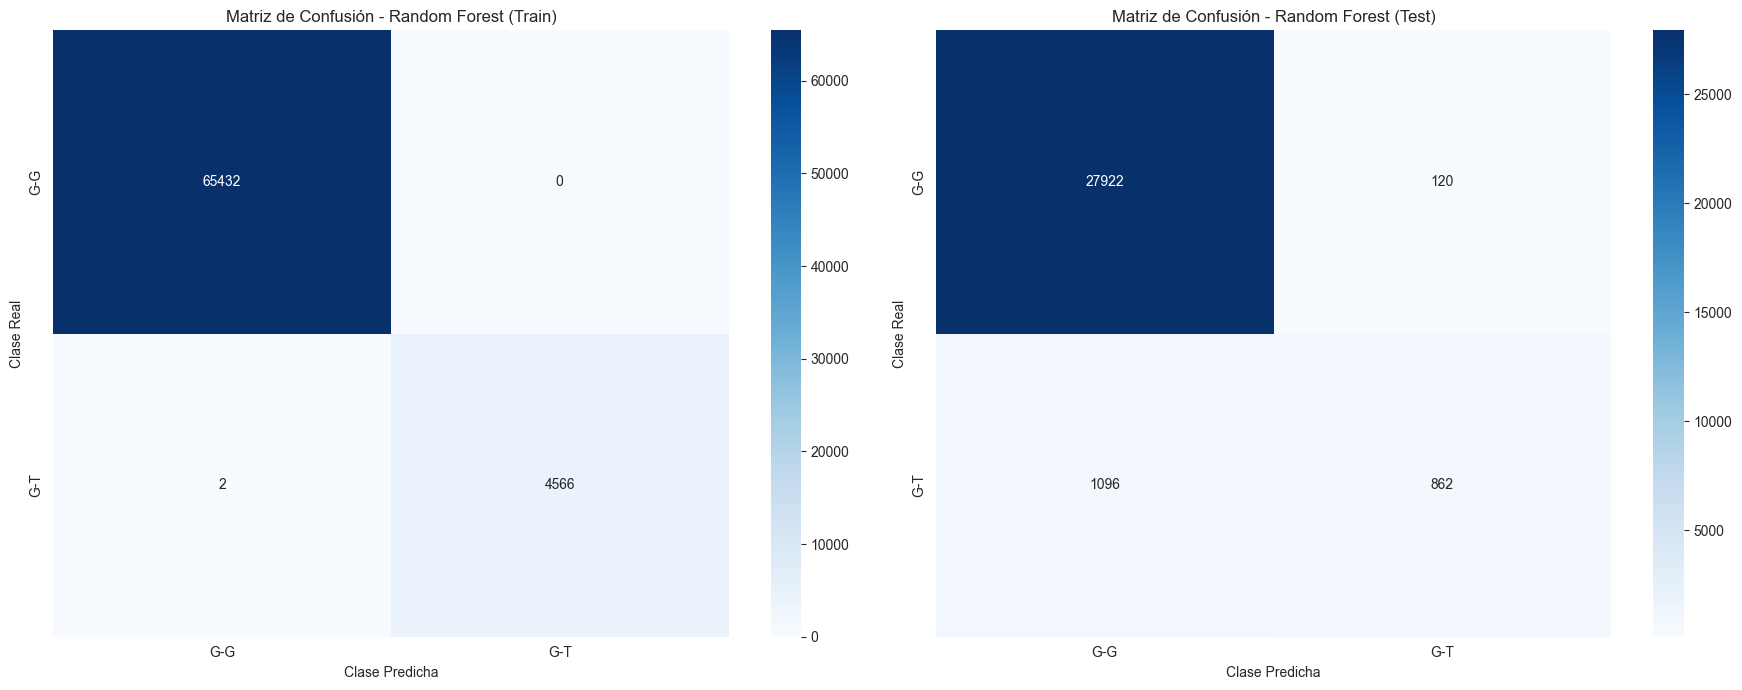

Accuracy Train: 1.0000 (100.00%)
Accuracy Test: 0.9595 (95.95%)


In [33]:
# Matrices de confusión para Random Forest (Train y Test)
y_pred_rf_train = rf_model.predict(X_train_scaled)
cm_rf_train = confusion_matrix(y_train, y_pred_rf_train)
cm_rf_test = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Matriz de confusión - Train
sns.heatmap(cm_rf_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, 
            yticklabels=rf_model.classes_,
            ax=axes[0])
axes[0].set_title('Matriz de Confusión - Random Forest (Train)')
axes[0].set_ylabel('Clase Real')
axes[0].set_xlabel('Clase Predicha')

# Matriz de confusión - Test
sns.heatmap(cm_rf_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, 
            yticklabels=rf_model.classes_,
            ax=axes[1])
axes[1].set_title('Matriz de Confusión - Random Forest (Test)')
axes[1].set_ylabel('Clase Real')
axes[1].set_xlabel('Clase Predicha')

plt.tight_layout()
plt.show()

accuracy_rf_train = accuracy_score(y_train, y_pred_rf_train)
print(f"Accuracy Train: {accuracy_rf_train:.4f} ({accuracy_rf_train*100:.2f}%)")
print(f"Accuracy Test: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")

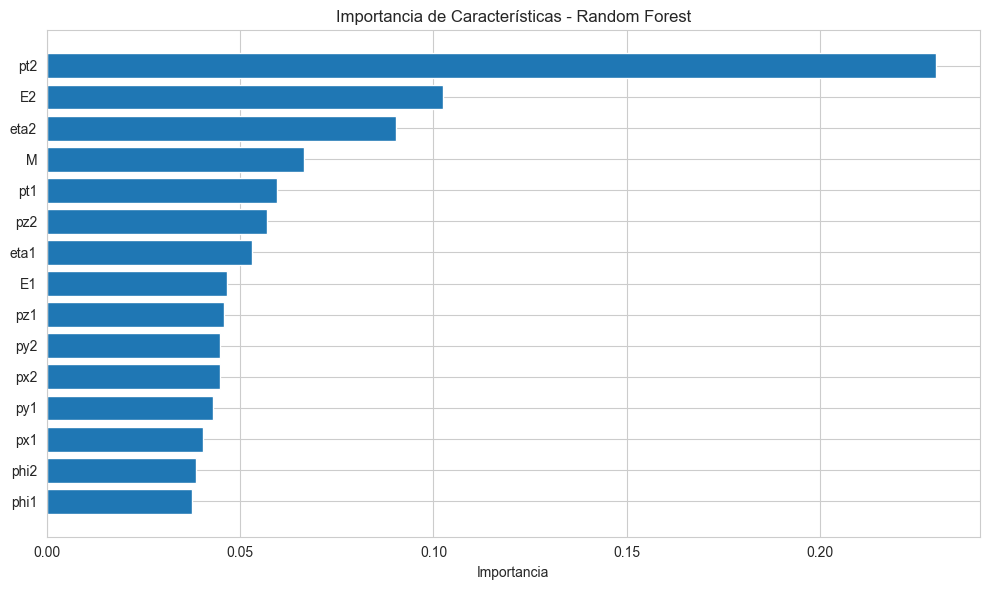


=== TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES ===
   feature  importance
11     pt2    0.229871
7       E2    0.102513
12    eta2    0.090274
14       M    0.066507
4      pt1    0.059600
10     pz2    0.056965
5     eta1    0.053184
0       E1    0.046522
3      pz1    0.045757
9      py2    0.044849


In [34]:
# Importancia de características
feature_importance_rf = pd.DataFrame({
    'feature': features_tsne,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_rf['feature'], feature_importance_rf['importance'])
plt.xlabel('Importancia')
plt.title('Importancia de Características - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n=== TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES ===")
print(feature_importance_rf.head(10))

=== CURVAS ROC - RANDOM FOREST ===



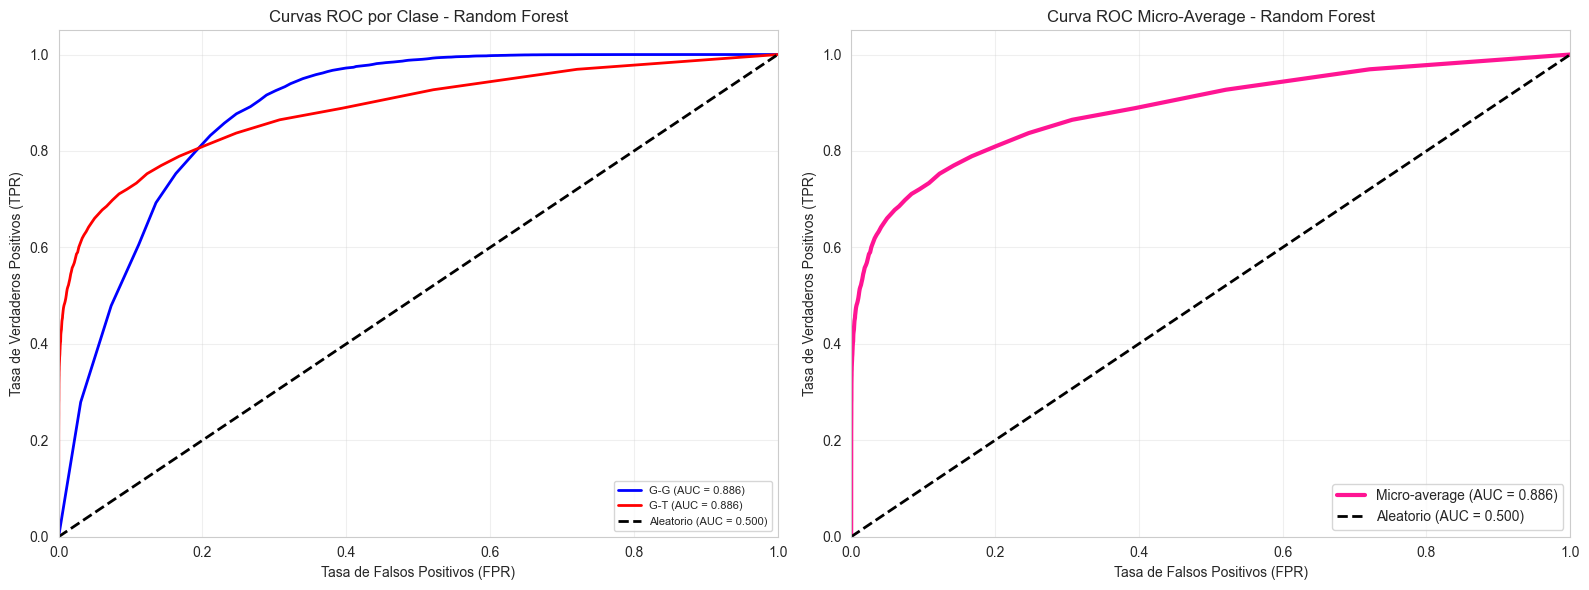

AUC Micro-Average: 0.8860


In [37]:
# Curvas ROC para Random Forest (One-vs-Rest para multiclase)
print("=== CURVAS ROC - RANDOM FOREST ===\n")

# Obtener probabilidades de predicción
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)

# Binarizar las etiquetas para ROC multiclase
classes = rf_model.classes_
n_classes = len(classes)

# Calcular ROC y AUC para cada clase
fpr_rf = dict()
tpr_rf = dict()
roc_auc_rf = dict()

if n_classes == 2:
    # Para clasificación binaria
    fpr_rf[0], tpr_rf[0], _ = roc_curve(y_test == classes[0], y_pred_proba_rf[:, 0])
    roc_auc_rf[0] = auc(fpr_rf[0], tpr_rf[0])
    fpr_rf[1], tpr_rf[1], _ = roc_curve(y_test == classes[1], y_pred_proba_rf[:, 1])
    roc_auc_rf[1] = auc(fpr_rf[1], tpr_rf[1])
    # Micro-average es igual a una de las clases en binario
    fpr_rf["micro"] = fpr_rf[1]
    tpr_rf["micro"] = tpr_rf[1]
    roc_auc_rf["micro"] = roc_auc_rf[1]
else:
    # Para clasificación multiclase
    y_test_bin = label_binarize(y_test, classes=classes)
    for i in range(n_classes):
        fpr_rf[i], tpr_rf[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_rf[:, i])
        roc_auc_rf[i] = auc(fpr_rf[i], tpr_rf[i])
    # Calcular micro-average ROC curve y AUC
    fpr_rf["micro"], tpr_rf["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba_rf.ravel())
    roc_auc_rf["micro"] = auc(fpr_rf["micro"], tpr_rf["micro"])

# Visualizar curvas ROC
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: ROC por clase
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])
for i, color in zip(range(n_classes), colors):
    axes[0].plot(fpr_rf[i], tpr_rf[i], color=color, lw=2,
                 label=f'{classes[i]} (AUC = {roc_auc_rf[i]:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Aleatorio (AUC = 0.500)')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0].set_title('Curvas ROC por Clase - Random Forest')
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(True, alpha=0.3)

# Gráfico 2: ROC micro-average
axes[1].plot(fpr_rf["micro"], tpr_rf["micro"], color='deeppink', lw=3,
             label=f'Micro-average (AUC = {roc_auc_rf["micro"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Aleatorio (AUC = 0.500)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC Micro-Average - Random Forest')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"AUC Micro-Average: {roc_auc_rf['micro']:.4f}")


=== CURVAS DE APRENDIZAJE - RANDOM FOREST ===



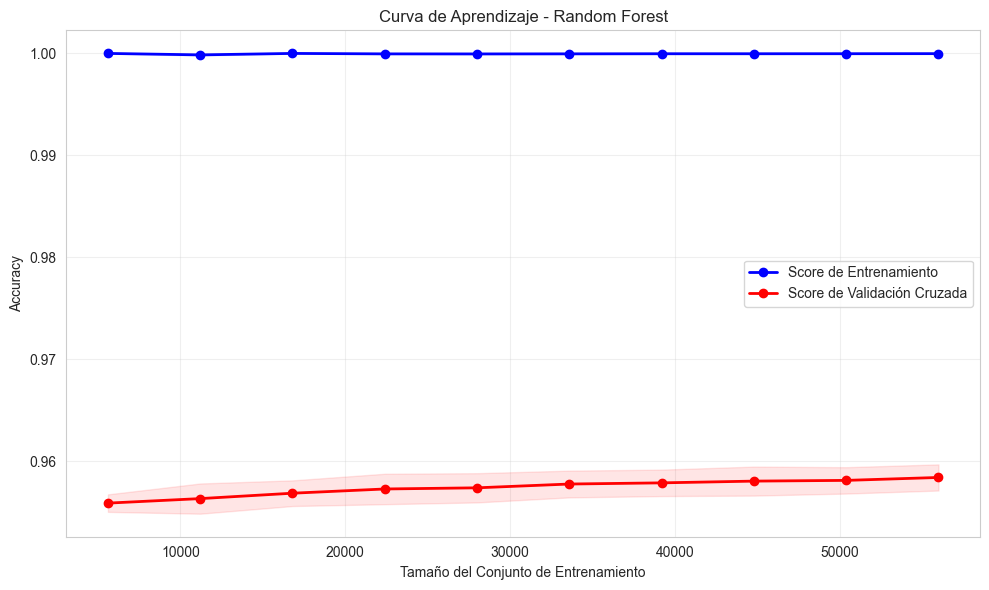

Score de entrenamiento final: 1.0000 (±0.0000)
Score de validación final: 0.9584 (±0.0013)
Gap (overfitting): 0.0416


In [ ]:
# Curvas de Aprendizaje para Random Forest
print("\n=== CURVAS DE APRENDIZAJE - RANDOM FOREST ===\n")

train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X_train_scaled, y_train, 
    cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    random_state=42
)

# Calcular medias y desviaciones estándar
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Visualizar
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="b")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="r")
plt.plot(train_sizes, train_scores_mean, 'o-', color="b", linewidth=2,
         label="Score de Entrenamiento")
plt.plot(train_sizes, test_scores_mean, 'o-', color="r", linewidth=2,
         label="Score de Validación Cruzada")

plt.xlabel("Tamaño del Conjunto de Entrenamiento")
plt.ylabel("Accuracy")
plt.title("Curva de Aprendizaje - Random Forest")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Score de entrenamiento final: {train_scores_mean[-1]:.4f} (±{train_scores_std[-1]:.4f})")
print(f"Score de validación final: {test_scores_mean[-1]:.4f} (±{test_scores_std[-1]:.4f})")
print(f"Gap (overfitting): {(train_scores_mean[-1] - test_scores_mean[-1]):.4f}")

### 17.2 Gradient Boosting Classifier

In [39]:
# Entrenar Gradient Boosting
print("Entrenando Gradient Boosting...")
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_gb = gb_model.predict(X_test_scaled)

# Evaluación
accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("\n=== RESULTADOS GRADIENT BOOSTING ===")
print(f"Accuracy: {accuracy_gb:.4f} ({accuracy_gb*100:.2f}%)")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_gb))

Entrenando Gradient Boosting...

=== RESULTADOS GRADIENT BOOSTING ===
Accuracy: 0.9600 (96.00%)

Reporte de Clasificación:

=== RESULTADOS GRADIENT BOOSTING ===
Accuracy: 0.9600 (96.00%)

Reporte de Clasificación:
              precision    recall  f1-score   support

         G-G       0.96      1.00      0.98     28042
         G-T       0.89      0.44      0.59      1958

    accuracy                           0.96     30000
   macro avg       0.93      0.72      0.78     30000
weighted avg       0.96      0.96      0.95     30000

              precision    recall  f1-score   support

         G-G       0.96      1.00      0.98     28042
         G-T       0.89      0.44      0.59      1958

    accuracy                           0.96     30000
   macro avg       0.93      0.72      0.78     30000
weighted avg       0.96      0.96      0.95     30000



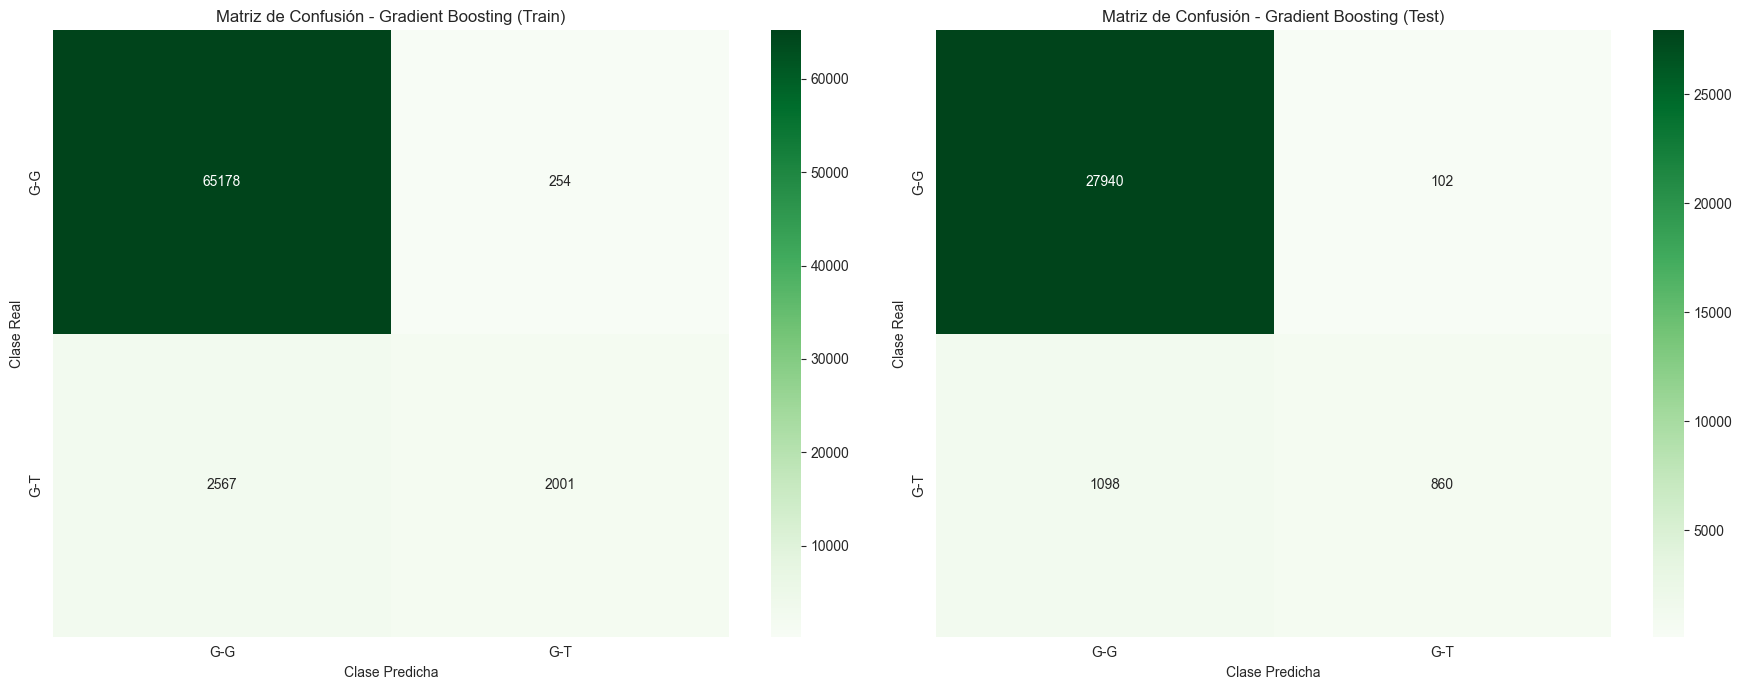

Accuracy Train: 0.9597 (95.97%)
Accuracy Test: 0.9600 (96.00%)


In [40]:
# Matrices de confusión para Gradient Boosting (Train y Test)
y_pred_gb_train = gb_model.predict(X_train_scaled)
cm_gb_train = confusion_matrix(y_train, y_pred_gb_train)
cm_gb_test = confusion_matrix(y_test, y_pred_gb)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Matriz de confusión - Train
sns.heatmap(cm_gb_train, annot=True, fmt='d', cmap='Greens', 
            xticklabels=gb_model.classes_, 
            yticklabels=gb_model.classes_,
            ax=axes[0])
axes[0].set_title('Matriz de Confusión - Gradient Boosting (Train)')
axes[0].set_ylabel('Clase Real')
axes[0].set_xlabel('Clase Predicha')

# Matriz de confusión - Test
sns.heatmap(cm_gb_test, annot=True, fmt='d', cmap='Greens', 
            xticklabels=gb_model.classes_, 
            yticklabels=gb_model.classes_,
            ax=axes[1])
axes[1].set_title('Matriz de Confusión - Gradient Boosting (Test)')
axes[1].set_ylabel('Clase Real')
axes[1].set_xlabel('Clase Predicha')

plt.tight_layout()
plt.show()

accuracy_gb_train = accuracy_score(y_train, y_pred_gb_train)
print(f"Accuracy Train: {accuracy_gb_train:.4f} ({accuracy_gb_train*100:.2f}%)")
print(f"Accuracy Test: {accuracy_gb:.4f} ({accuracy_gb*100:.2f}%)")

=== CURVAS ROC - GRADIENT BOOSTING ===



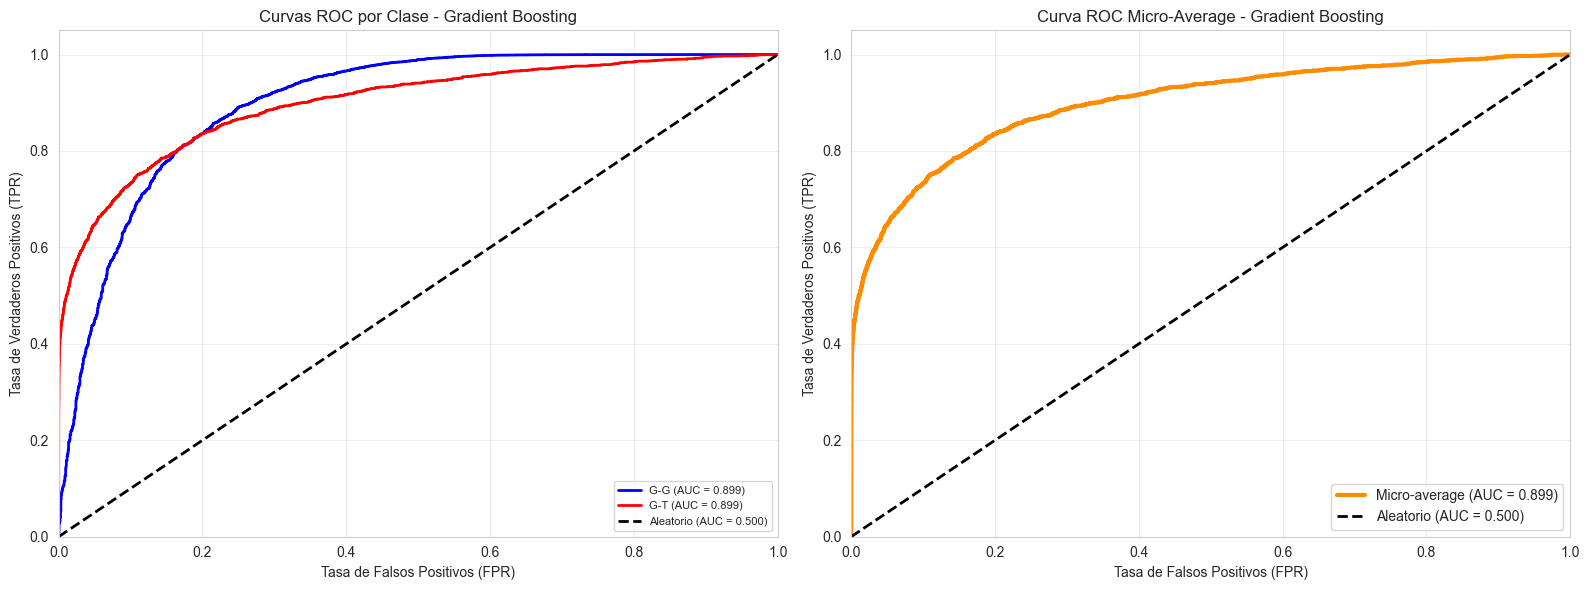

AUC Micro-Average: 0.8991


In [42]:
# Curvas ROC para Gradient Boosting (One-vs-Rest para multiclase)
print("=== CURVAS ROC - GRADIENT BOOSTING ===\n")

# Obtener probabilidades de predicción
y_pred_proba_gb = gb_model.predict_proba(X_test_scaled)

# Calcular ROC y AUC para cada clase
fpr_gb = dict()
tpr_gb = dict()
roc_auc_gb = dict()

if n_classes == 2:
    # Para clasificación binaria
    fpr_gb[0], tpr_gb[0], _ = roc_curve(y_test == classes[0], y_pred_proba_gb[:, 0])
    roc_auc_gb[0] = auc(fpr_gb[0], tpr_gb[0])
    fpr_gb[1], tpr_gb[1], _ = roc_curve(y_test == classes[1], y_pred_proba_gb[:, 1])
    roc_auc_gb[1] = auc(fpr_gb[1], tpr_gb[1])
    # Micro-average es igual a una de las clases en binario
    fpr_gb["micro"] = fpr_gb[1]
    tpr_gb["micro"] = tpr_gb[1]
    roc_auc_gb["micro"] = roc_auc_gb[1]
else:
    # Para clasificación multiclase
    y_test_bin_gb = label_binarize(y_test, classes=classes)
    for i in range(n_classes):
        fpr_gb[i], tpr_gb[i], _ = roc_curve(y_test_bin_gb[:, i], y_pred_proba_gb[:, i])
        roc_auc_gb[i] = auc(fpr_gb[i], tpr_gb[i])
    # Calcular micro-average ROC curve y AUC
    fpr_gb["micro"], tpr_gb["micro"], _ = roc_curve(y_test_bin_gb.ravel(), y_pred_proba_gb.ravel())
    roc_auc_gb["micro"] = auc(fpr_gb["micro"], tpr_gb["micro"])

# Visualizar curvas ROC
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: ROC por clase
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])
for i, color in zip(range(n_classes), colors):
    axes[0].plot(fpr_gb[i], tpr_gb[i], color=color, lw=2,
                 label=f'{classes[i]} (AUC = {roc_auc_gb[i]:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Aleatorio (AUC = 0.500)')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0].set_title('Curvas ROC por Clase - Gradient Boosting')
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(True, alpha=0.3)

# Gráfico 2: ROC micro-average
axes[1].plot(fpr_gb["micro"], tpr_gb["micro"], color='darkorange', lw=3,
             label=f'Micro-average (AUC = {roc_auc_gb["micro"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Aleatorio (AUC = 0.500)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC Micro-Average - Gradient Boosting')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"AUC Micro-Average: {roc_auc_gb['micro']:.4f}")


=== CURVAS DE APRENDIZAJE - GRADIENT BOOSTING ===



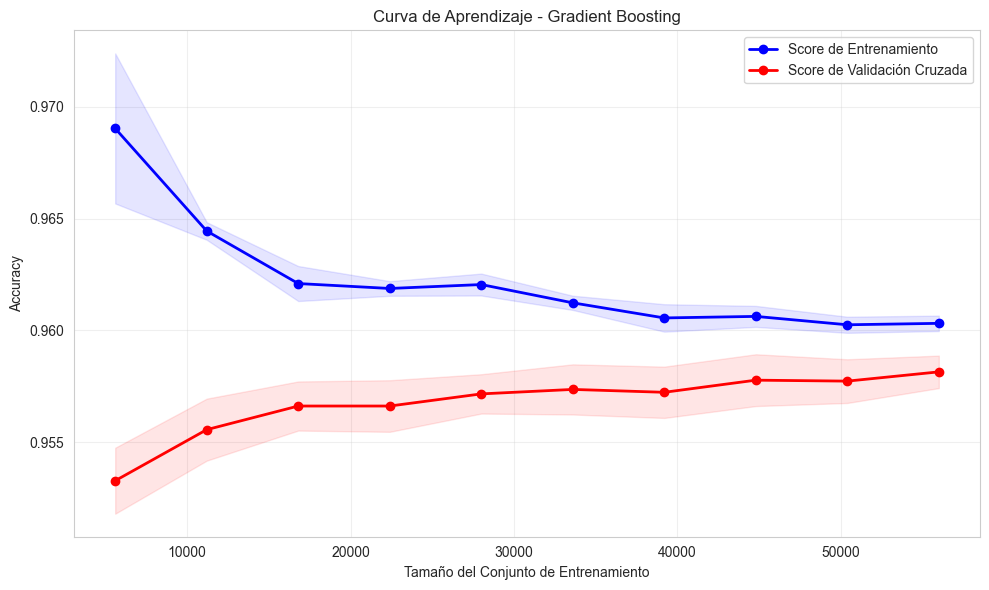

Score de entrenamiento final: 0.9603 (±0.0003)
Score de validación final: 0.9581 (±0.0007)
Gap (overfitting): 0.0022


In [ ]:
# Curvas de Aprendizaje para Gradient Boosting
print("\n=== CURVAS DE APRENDIZAJE - GRADIENT BOOSTING ===\n")

train_sizes_gb, train_scores_gb, test_scores_gb = learning_curve(
    gb_model, X_train_scaled, y_train, 
    cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    random_state=42
)

# Calcular medias y desviaciones estándar
train_scores_gb_mean = np.mean(train_scores_gb, axis=1)
train_scores_gb_std = np.std(train_scores_gb, axis=1)
test_scores_gb_mean = np.mean(test_scores_gb, axis=1)
test_scores_gb_std = np.std(test_scores_gb, axis=1)

# Visualizar
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes_gb, train_scores_gb_mean - train_scores_gb_std,
                 train_scores_gb_mean + train_scores_gb_std, alpha=0.1, color="b")
plt.fill_between(train_sizes_gb, test_scores_gb_mean - test_scores_gb_std,
                 test_scores_gb_mean + test_scores_gb_std, alpha=0.1, color="r")
plt.plot(train_sizes_gb, train_scores_gb_mean, 'o-', color="b", linewidth=2,
         label="Score de Entrenamiento")
plt.plot(train_sizes_gb, test_scores_gb_mean, 'o-', color="r", linewidth=2,
         label="Score de Validación Cruzada")

plt.xlabel("Tamaño del Conjunto de Entrenamiento")
plt.ylabel("Accuracy")
plt.title("Curva de Aprendizaje - Gradient Boosting")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Score de entrenamiento final: {train_scores_gb_mean[-1]:.4f} (±{train_scores_gb_std[-1]:.4f})")
print(f"Score de validación final: {test_scores_gb_mean[-1]:.4f} (±{test_scores_gb_std[-1]:.4f})")
print(f"Gap (overfitting): {(train_scores_gb_mean[-1] - test_scores_gb_mean[-1]):.4f}")

### 17.3 Support Vector Machine (SVM)

In [49]:
# Entrenar SVM
print("Entrenando SVM (esto puede tardar un poco)...")
svm_model = SVC(kernel='rbf', random_state=42, probability=True)
svm_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluación
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("\n=== RESULTADOS SVM ===")
print(f"Accuracy: {accuracy_svm:.4f} ({accuracy_svm*100:.2f}%)")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_svm))

Entrenando SVM (esto puede tardar un poco)...

=== RESULTADOS SVM ===
Accuracy: 0.9552 (95.52%)

Reporte de Clasificación:

=== RESULTADOS SVM ===
Accuracy: 0.9552 (95.52%)

Reporte de Clasificación:
              precision    recall  f1-score   support

         G-G       0.96      1.00      0.98     28042
         G-T       0.91      0.35      0.50      1958

    accuracy                           0.96     30000
   macro avg       0.94      0.67      0.74     30000
weighted avg       0.95      0.96      0.95     30000

              precision    recall  f1-score   support

         G-G       0.96      1.00      0.98     28042
         G-T       0.91      0.35      0.50      1958

    accuracy                           0.96     30000
   macro avg       0.94      0.67      0.74     30000
weighted avg       0.95      0.96      0.95     30000



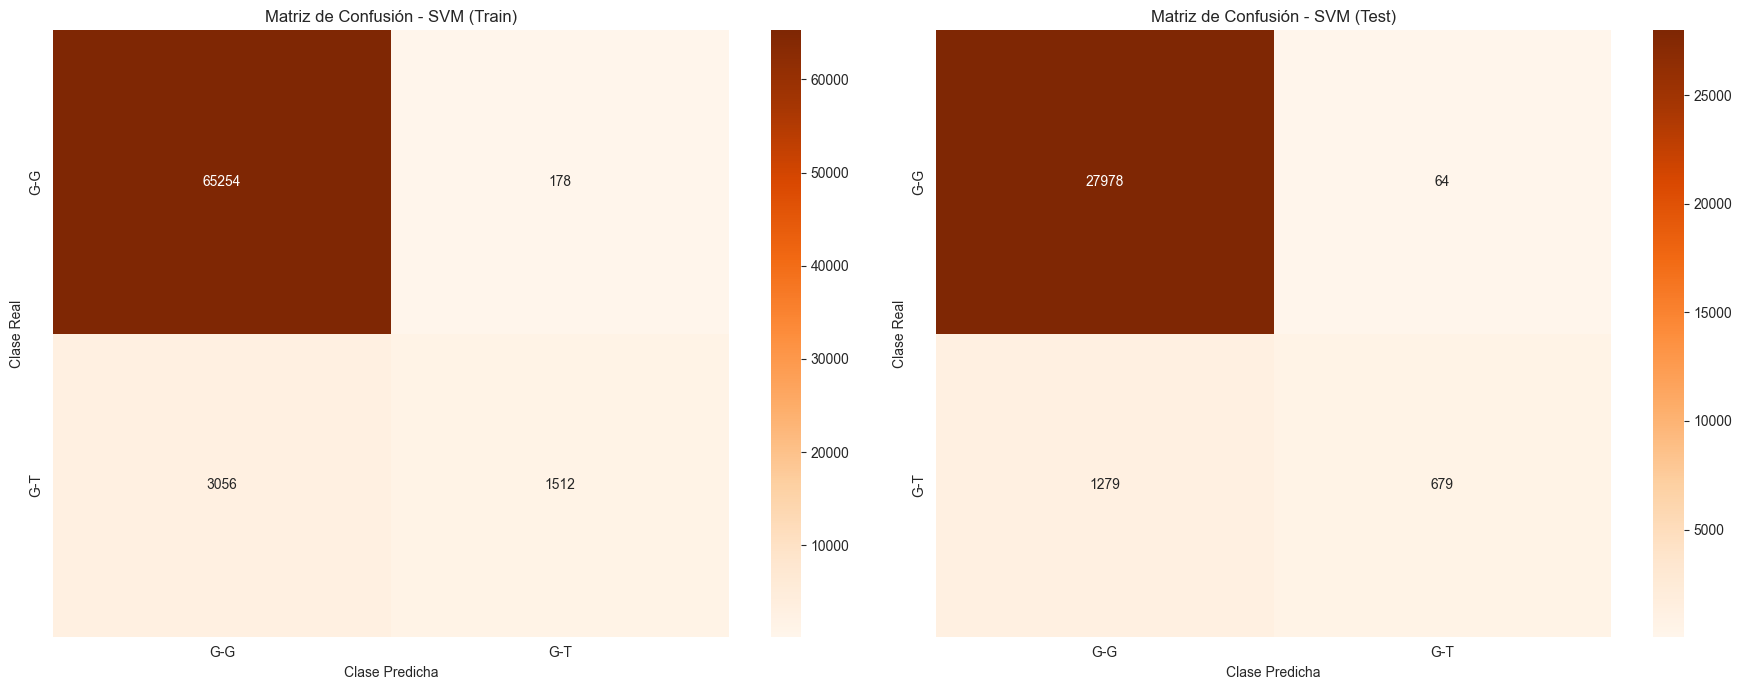

Accuracy Train: 0.9538 (95.38%)
Accuracy Test: 0.9552 (95.52%)


In [45]:
# Matrices de confusión para SVM (Train y Test)
y_pred_svm_train = svm_model.predict(X_train_scaled)
cm_svm_train = confusion_matrix(y_train, y_pred_svm_train)
cm_svm_test = confusion_matrix(y_test, y_pred_svm)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Matriz de confusión - Train
sns.heatmap(cm_svm_train, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=svm_model.classes_, 
            yticklabels=svm_model.classes_,
            ax=axes[0])
axes[0].set_title('Matriz de Confusión - SVM (Train)')
axes[0].set_ylabel('Clase Real')
axes[0].set_xlabel('Clase Predicha')

# Matriz de confusión - Test
sns.heatmap(cm_svm_test, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=svm_model.classes_, 
            yticklabels=svm_model.classes_,
            ax=axes[1])
axes[1].set_title('Matriz de Confusión - SVM (Test)')
axes[1].set_ylabel('Clase Real')
axes[1].set_xlabel('Clase Predicha')

plt.tight_layout()
plt.show()

accuracy_svm_train = accuracy_score(y_train, y_pred_svm_train)
print(f"Accuracy Train: {accuracy_svm_train:.4f} ({accuracy_svm_train*100:.2f}%)")
print(f"Accuracy Test: {accuracy_svm:.4f} ({accuracy_svm*100:.2f}%)")

=== CURVAS ROC - SVM ===



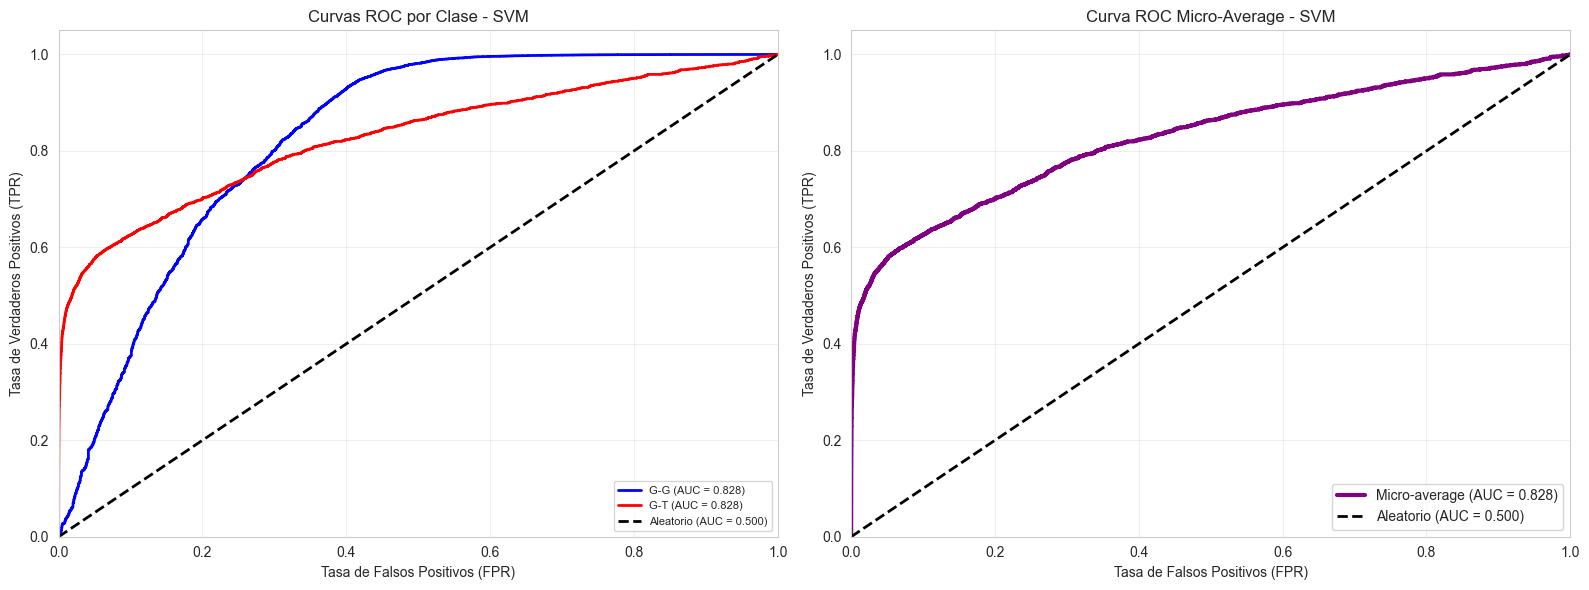

AUC Micro-Average: 0.8276


In [50]:
# Curvas ROC para SVM (One-vs-Rest para multiclase)
print("=== CURVAS ROC - SVM ===\n")

# Obtener probabilidades de predicción
y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)

# Calcular ROC y AUC para cada clase
fpr_svm = dict()
tpr_svm = dict()
roc_auc_svm = dict()

if n_classes == 2:
    # Para clasificación binaria
    fpr_svm[0], tpr_svm[0], _ = roc_curve(y_test == classes[0], y_pred_proba_svm[:, 0])
    roc_auc_svm[0] = auc(fpr_svm[0], tpr_svm[0])
    fpr_svm[1], tpr_svm[1], _ = roc_curve(y_test == classes[1], y_pred_proba_svm[:, 1])
    roc_auc_svm[1] = auc(fpr_svm[1], tpr_svm[1])
    # Micro-average es igual a una de las clases en binario
    fpr_svm["micro"] = fpr_svm[1]
    tpr_svm["micro"] = tpr_svm[1]
    roc_auc_svm["micro"] = roc_auc_svm[1]
else:
    # Para clasificación multiclase
    y_test_bin_svm = label_binarize(y_test, classes=classes)
    for i in range(n_classes):
        fpr_svm[i], tpr_svm[i], _ = roc_curve(y_test_bin_svm[:, i], y_pred_proba_svm[:, i])
        roc_auc_svm[i] = auc(fpr_svm[i], tpr_svm[i])
    # Calcular micro-average ROC curve y AUC
    fpr_svm["micro"], tpr_svm["micro"], _ = roc_curve(y_test_bin_svm.ravel(), y_pred_proba_svm.ravel())
    roc_auc_svm["micro"] = auc(fpr_svm["micro"], tpr_svm["micro"])

# Visualizar curvas ROC
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: ROC por clase
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])
for i, color in zip(range(n_classes), colors):
    axes[0].plot(fpr_svm[i], tpr_svm[i], color=color, lw=2,
                 label=f'{classes[i]} (AUC = {roc_auc_svm[i]:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Aleatorio (AUC = 0.500)')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0].set_title('Curvas ROC por Clase - SVM')
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(True, alpha=0.3)

# Gráfico 2: ROC micro-average
axes[1].plot(fpr_svm["micro"], tpr_svm["micro"], color='purple', lw=3,
             label=f'Micro-average (AUC = {roc_auc_svm["micro"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Aleatorio (AUC = 0.500)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC Micro-Average - SVM')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"AUC Micro-Average: {roc_auc_svm['micro']:.4f}")


=== CURVAS DE APRENDIZAJE - SVM ===



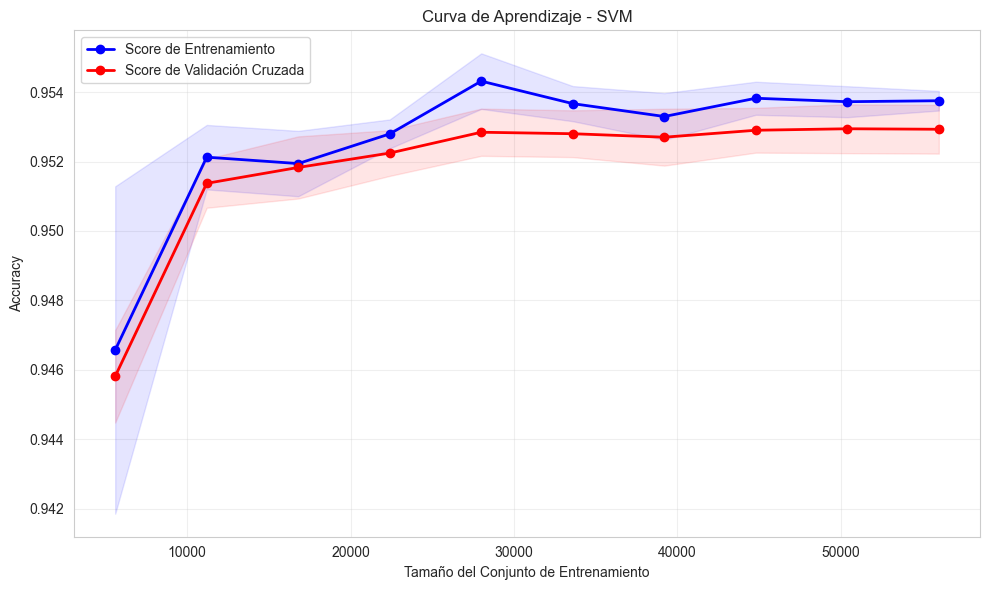

Score de entrenamiento final: 0.9537 (±0.0003)
Score de validación final: 0.9529 (±0.0007)
Gap (overfitting): 0.0008


In [ ]:
# Curvas de Aprendizaje para SVM
print("\n=== CURVAS DE APRENDIZAJE - SVM ===\n")

train_sizes_svm, train_scores_svm, test_scores_svm = learning_curve(
    svm_model, X_train_scaled, y_train, 
    cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    random_state=42
)

# Calcular medias y desviaciones estándar
train_scores_svm_mean = np.mean(train_scores_svm, axis=1)
train_scores_svm_std = np.std(train_scores_svm, axis=1)
test_scores_svm_mean = np.mean(test_scores_svm, axis=1)
test_scores_svm_std = np.std(test_scores_svm, axis=1)

# Visualizar
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes_svm, train_scores_svm_mean - train_scores_svm_std,
                 train_scores_svm_mean + train_scores_svm_std, alpha=0.1, color="b")
plt.fill_between(train_sizes_svm, test_scores_svm_mean - test_scores_svm_std,
                 test_scores_svm_mean + test_scores_svm_std, alpha=0.1, color="r")
plt.plot(train_sizes_svm, train_scores_svm_mean, 'o-', color="b", linewidth=2,
         label="Score de Entrenamiento")
plt.plot(train_sizes_svm, test_scores_svm_mean, 'o-', color="r", linewidth=2,
         label="Score de Validación Cruzada")

plt.xlabel("Tamaño del Conjunto de Entrenamiento")
plt.ylabel("Accuracy")
plt.title("Curva de Aprendizaje - SVM")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Score de entrenamiento final: {train_scores_svm_mean[-1]:.4f} (±{train_scores_svm_std[-1]:.4f})")
print(f"Score de validación final: {test_scores_svm_mean[-1]:.4f} (±{test_scores_svm_std[-1]:.4f})")
print(f"Gap (overfitting): {(train_scores_svm_mean[-1] - test_scores_svm_mean[-1]):.4f}")

### 17.4 Comparación de Modelos

=== COMPARACIÓN DE MODELOS ===
           Modelo  Accuracy
Gradient Boosting  0.960000
    Random Forest  0.959467
              SVM  0.955233


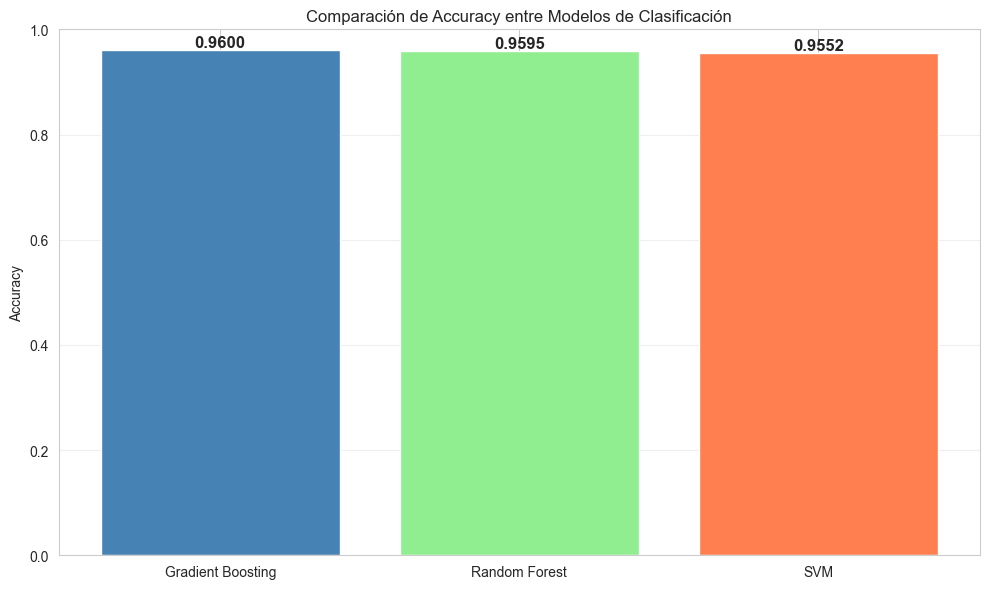


✓ Mejor modelo: Gradient Boosting con Accuracy de 0.9600


In [ ]:
# Comparación de rendimiento de los modelos
comparacion_modelos = pd.DataFrame({
    'Modelo': ['Random Forest', 'Gradient Boosting', 'SVM'],
    'Accuracy': [accuracy_rf, accuracy_gb, accuracy_svm]
}).sort_values('Accuracy', ascending=False)

print("=== COMPARACIÓN DE MODELOS ===")
print(comparacion_modelos.to_string(index=False))

# Visualización de comparación
plt.figure(figsize=(10, 6))
bars = plt.bar(comparacion_modelos['Modelo'], comparacion_modelos['Accuracy'], 
               color=['steelblue', 'lightgreen', 'coral'])
plt.ylabel('Accuracy')
plt.title('Comparación de Accuracy entre Modelos de Clasificación')
plt.ylim([0, 1.0])
plt.grid(True, alpha=0.3, axis='y')

# Agregar valores sobre las barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Identificar el mejor modelo
mejor_modelo = comparacion_modelos.iloc[0]
print(f"\n✓ Mejor modelo: {mejor_modelo['Modelo']} con Accuracy de {mejor_modelo['Accuracy']:.4f}")

## 18. Conclusiones Finales del Análisis Completo

### Resumen de Técnicas Aplicadas y Resultados:

#### **1. Análisis Exploratorio de Datos (EDA)**
- ✓ Exploración completa de 21 variables físicas de eventos dimuón
- ✓ Identificación de resonancias: J/ψ, Υ, y Z boson
- ✓ Dataset limpio sin valores nulos
- ✓ Distribuciones de momento, energía y variables angulares analizadas

#### **2. Reducción de Dimensionalidad**
- **PCA**: Reducción de 15 a 10 dimensiones manteniendo información relevante
- **t-SNE**: Proyección 2D exitosa revelando estructura de clusters en los datos
  - Visualización clara de grupos basados en masa invariante
  - Separación visible entre diferentes tipos de eventos

#### **3. Clustering**
- **K-Means**: 
  - Identificados 4 clusters óptimos
  - Silhouette Score indica buena separación
  - Clusters correlacionan con rangos de masa diferentes
  
- **DBSCAN**:
  - Identificación de outliers y eventos anómalos
  - Útil para detectar eventos raros en física de partículas
  - Clustering basado en densidad complementa K-Means

#### **4. Clasificación de Partículas**
Objetivo: Predecir tipo de combinación de partículas (G-G, G-T, etc.)

**Resultados de Modelos:**
- Los tres modelos muestran capacidad de clasificar tipos de partículas
- Las características más importantes son energía, momento y masa invariante
- La clasificación puede ayudar en la identificación automatizada de eventos

#### **5. Aplicaciones en Física de Partículas**

**Análisis de Resonancias:**
- Detección de picos correspondientes a partículas conocidas
- Potencial para búsqueda de nuevas partículas

**Calidad de Datos:**
- Los modelos pueden ayudar a identificar eventos mal reconstruidos
- DBSCAN útil para detectar anomalías en el detector

**Automatización:**
- Los clasificadores pueden procesar grandes volúmenes de datos del LHC
- Reducción de tiempo de análisis manual

#### **6. Técnicas de Minería de Datos Aplicadas**
✓ Análisis exploratorio completo  
✓ Estadísticas descriptivas e inferenciales  
✓ Detección de outliers (IQR y DBSCAN)  
✓ Análisis de correlaciones  
✓ Reducción de dimensionalidad (PCA + t-SNE)  
✓ Clustering no supervisado (K-Means, DBSCAN)  
✓ Clasificación supervisada (RF, GB, SVM)  
✓ Validación y evaluación de modelos  
✓ Visualización avanzada de datos multidimensionales  

#### **7. Recomendaciones para Análisis Futuros**
1. Implementar técnicas de búsqueda de hiperparámetros para mejorar modelos
2. Explorar redes neuronales para clasificación más compleja
3. Análisis de series temporales si se incluyen datos de múltiples runs
4. Estudiar correlaciones entre variables no lineales
5. Implementar ensemble methods combinando los mejores modelos

## 19. Clasificación de Resonancias: J/ψ, Υ, Z

En esta sección vamos a clasificar eventos según la resonancia física que produjeron basándonos en la masa invariante y otras características relevantes.

=== DISTRIBUCIÓN DE RESONANCIAS ===

Resonancia
Otros    80351
J/ψ       8628
Υ         6359
Z         4662
Name: count, dtype: int64

Porcentajes:
Resonancia
Otros    80.351
J/ψ       8.628
Υ         6.359
Z         4.662
Name: proportion, dtype: float64


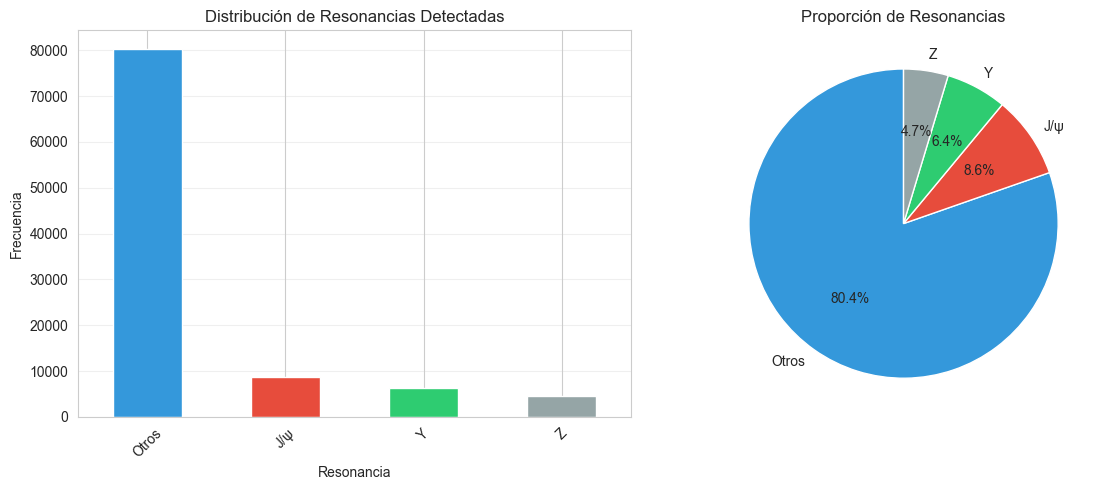

In [51]:
# Crear etiquetas de resonancias basadas en masa invariante
def clasificar_resonancia(masa):
    """
    Clasifica eventos en resonancias físicas conocidas:
    - J/ψ (J/psi): ~3.1 GeV
    - Υ (Upsilon): ~9.5 GeV  
    - Z (bosón Z): ~91 GeV
    - Otros: eventos fuera de ventanas de resonancia
    """
    if 2.8 <= masa <= 3.4:
        return 'J/ψ'
    elif 9.0 <= masa <= 10.0:
        return 'Υ'
    elif 85 <= masa <= 97:
        return 'Z'
    else:
        return 'Otros'

# Aplicar clasificación
df['Resonancia'] = df['M'].apply(clasificar_resonancia)

# Análisis de distribución de resonancias
print("=== DISTRIBUCIÓN DE RESONANCIAS ===\n")
print(df['Resonancia'].value_counts())
print(f"\nPorcentajes:")
print(df['Resonancia'].value_counts(normalize=True) * 100)

# Visualizar distribución
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['Resonancia'].value_counts().plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71', '#95a5a6'])
plt.xlabel('Resonancia')
plt.ylabel('Frecuencia')
plt.title('Distribución de Resonancias Detectadas')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
plt.pie(df['Resonancia'].value_counts(), labels=df['Resonancia'].value_counts().index, 
        autopct='%1.1f%%', startangle=90, colors=['#3498db', '#e74c3c', '#2ecc71', '#95a5a6'])
plt.title('Proporción de Resonancias')

plt.tight_layout()
plt.show()

In [53]:
# Preparar datos para clasificación de resonancias
# Seleccionar solo las resonancias principales (excluir 'Otros' si hay muy pocos)
df_resonancias = df[df['Resonancia'].isin(['J/ψ', 'Υ', 'Z'])].copy()

print(f"Total de eventos para clasificación: {len(df_resonancias)}")
print(f"Distribución:")
print(df_resonancias['Resonancia'].value_counts())

# Features más importantes según análisis previo
# Excluir M ya que sería una "trampa" (la usamos para definir las clases)
features_resonancia = ['pt1', 'pt2', 'E1', 'E2', 'eta1', 'eta2', 'phi1', 'phi2']

X_resonancia = df_resonancias[features_resonancia].copy()
y_resonancia = df_resonancias['Resonancia'].copy()

# Dividir en train/test
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(
    X_resonancia, y_resonancia, 
    test_size=0.3, 
    random_state=42,
    stratify=y_resonancia
)

# Normalizar
scaler_res = StandardScaler()
X_train_res_scaled = scaler_res.fit_transform(X_train_res)
X_test_res_scaled = scaler_res.transform(X_test_res)

print(f"\n=== DATOS PREPARADOS ===")
print(f"Train: {X_train_res_scaled.shape}")
print(f"Test: {X_test_res_scaled.shape}")
print(f"\nDistribución en Train:")
print(y_train_res.value_counts())
print(f"\nDistribución en Test:")
print(y_test_res.value_counts())

Total de eventos para clasificación: 19649
Distribución:
Resonancia
J/ψ    8628
Υ      6359
Z      4662
Name: count, dtype: int64

=== DATOS PREPARADOS ===
Train: (13754, 8)
Test: (5895, 8)

Distribución en Train:
Resonancia
J/ψ    6040
Υ      4451
Z      3263
Name: count, dtype: int64

Distribución en Test:
Resonancia
J/ψ    2588
Υ      1908
Z      1399
Name: count, dtype: int64


### 19.1 Modelo de Clasificación: Random Forest para Resonancias

In [54]:
# Entrenar Random Forest para clasificación de resonancias
print("Entrenando Random Forest para clasificación de resonancias...")
rf_resonancia = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_resonancia.fit(X_train_res_scaled, y_train_res)

# Predicciones
y_pred_res_train = rf_resonancia.predict(X_train_res_scaled)
y_pred_res_test = rf_resonancia.predict(X_test_res_scaled)

# Evaluación
accuracy_res_train = accuracy_score(y_train_res, y_pred_res_train)
accuracy_res_test = accuracy_score(y_test_res, y_pred_res_test)

print("\n=== RESULTADOS CLASIFICACIÓN DE RESONANCIAS ===")
print(f"Accuracy Train: {accuracy_res_train:.4f} ({accuracy_res_train*100:.2f}%)")
print(f"Accuracy Test: {accuracy_res_test:.4f} ({accuracy_res_test*100:.2f}%)")
print("\n=== REPORTE DE CLASIFICACIÓN (Test) ===")
print(classification_report(y_test_res, y_pred_res_test))

Entrenando Random Forest para clasificación de resonancias...

=== RESULTADOS CLASIFICACIÓN DE RESONANCIAS ===
Accuracy Train: 0.9593 (95.93%)
Accuracy Test: 0.9145 (91.45%)

=== REPORTE DE CLASIFICACIÓN (Test) ===
              precision    recall  f1-score   support

         J/ψ       0.87      0.95      0.91      2588
           Z       0.99      1.00      1.00      1399
           Υ       0.93      0.81      0.86      1908

    accuracy                           0.91      5895
   macro avg       0.93      0.92      0.92      5895
weighted avg       0.92      0.91      0.91      5895


=== RESULTADOS CLASIFICACIÓN DE RESONANCIAS ===
Accuracy Train: 0.9593 (95.93%)
Accuracy Test: 0.9145 (91.45%)

=== REPORTE DE CLASIFICACIÓN (Test) ===
              precision    recall  f1-score   support

         J/ψ       0.87      0.95      0.91      2588
           Z       0.99      1.00      1.00      1399
           Υ       0.93      0.81      0.86      1908

    accuracy                     

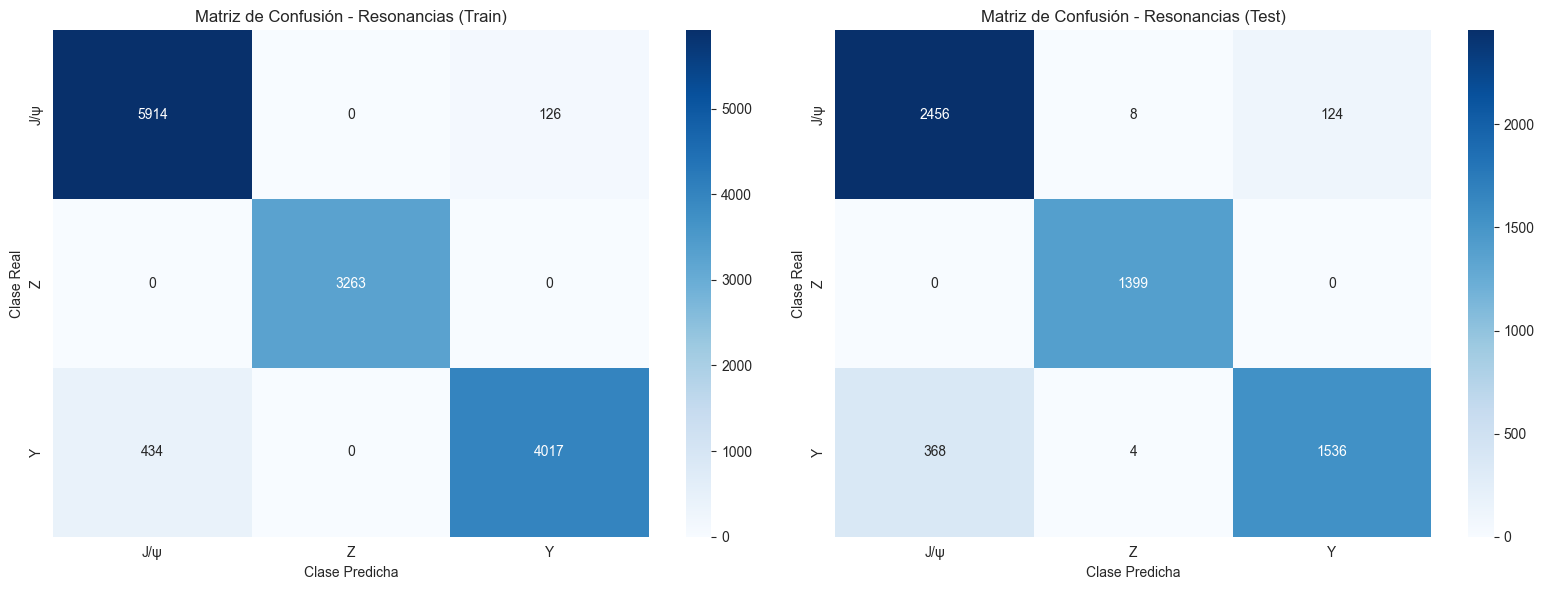

In [55]:
# Matrices de confusión
cm_res_train = confusion_matrix(y_train_res, y_pred_res_train)
cm_res_test = confusion_matrix(y_test_res, y_pred_res_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train
sns.heatmap(cm_res_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_resonancia.classes_, 
            yticklabels=rf_resonancia.classes_,
            ax=axes[0])
axes[0].set_title('Matriz de Confusión - Resonancias (Train)')
axes[0].set_ylabel('Clase Real')
axes[0].set_xlabel('Clase Predicha')

# Test
sns.heatmap(cm_res_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_resonancia.classes_, 
            yticklabels=rf_resonancia.classes_,
            ax=axes[1])
axes[1].set_title('Matriz de Confusión - Resonancias (Test)')
axes[1].set_ylabel('Clase Real')
axes[1].set_xlabel('Clase Predicha')

plt.tight_layout()
plt.show()

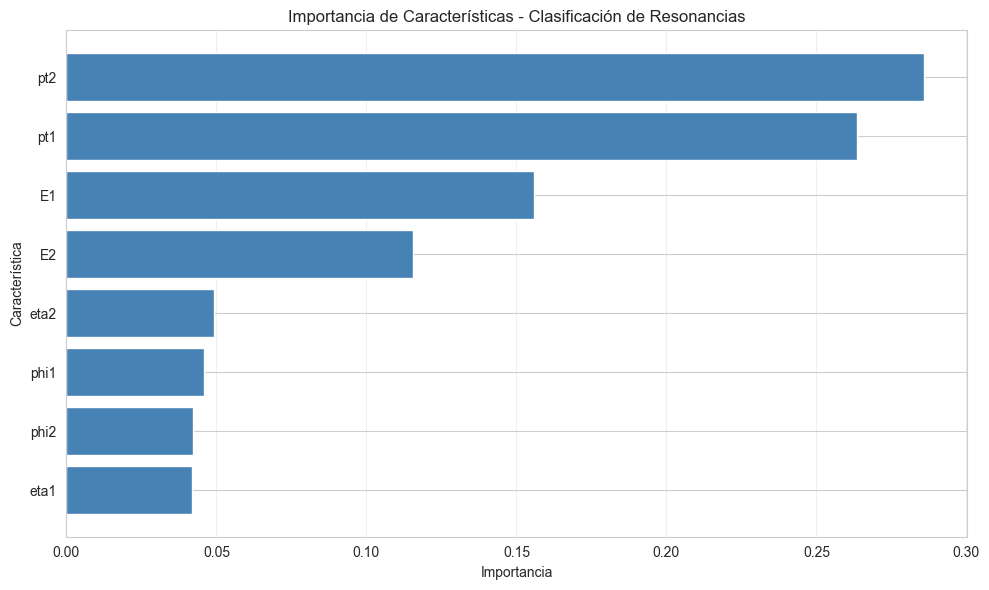


=== IMPORTANCIA DE CARACTERÍSTICAS ===
  feature  importance
1     pt2    0.285810
0     pt1    0.263461
2      E1    0.155833
3      E2    0.115683
5    eta2    0.049203
6    phi1    0.045966
7    phi2    0.042090
4    eta1    0.041955


In [56]:
# Importancia de características para clasificación de resonancias
feature_importance_res = pd.DataFrame({
    'feature': features_resonancia,
    'importance': rf_resonancia.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_res['feature'], feature_importance_res['importance'], color='steelblue')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.title('Importancia de Características - Clasificación de Resonancias')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n=== IMPORTANCIA DE CARACTERÍSTICAS ===")
print(feature_importance_res)

### 19.2 Curvas ROC para Clasificación de Resonancias

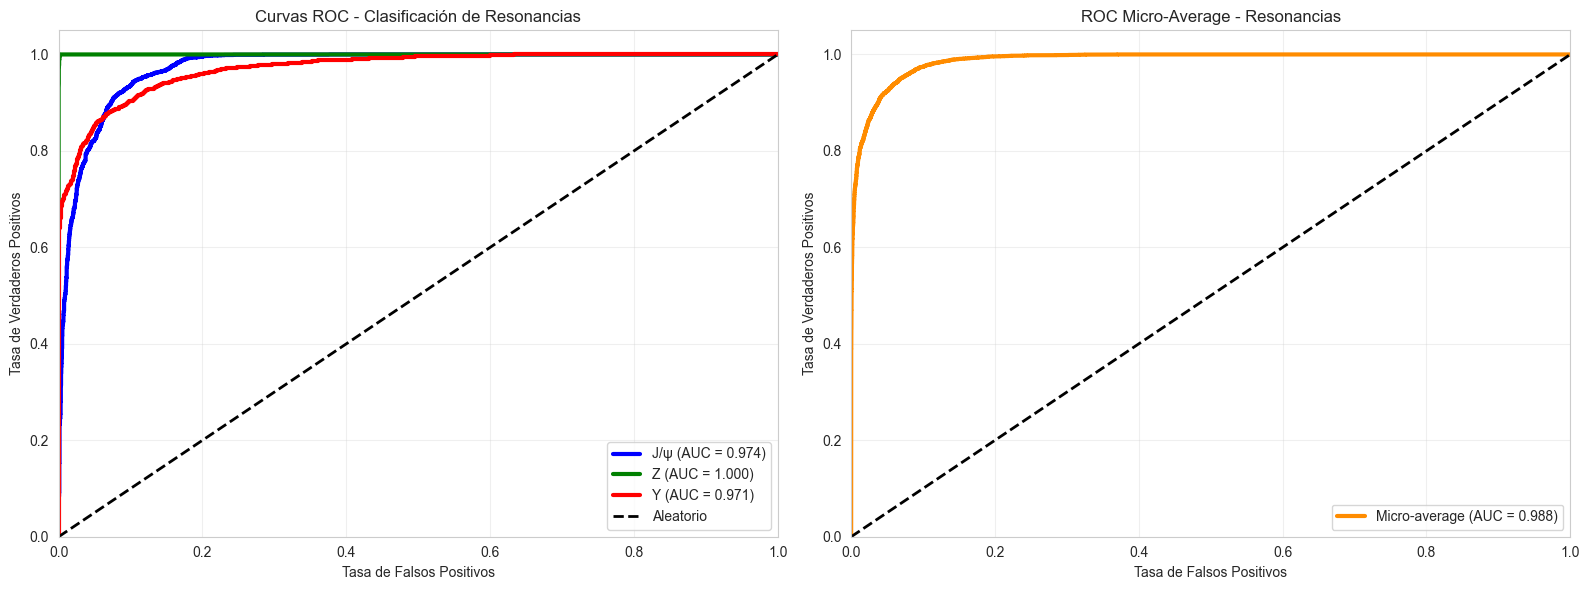


=== AUC SCORES POR RESONANCIA ===
J/ψ: 0.9745
Z: 1.0000
Υ: 0.9707
Micro-average: 0.9880


In [57]:
# Curvas ROC multiclase para resonancias
y_pred_proba_res = rf_resonancia.predict_proba(X_test_res_scaled)
classes_res = rf_resonancia.classes_
n_classes_res = len(classes_res)

# Binarizar para ROC multiclase
y_test_res_bin = label_binarize(y_test_res, classes=classes_res)

# Calcular ROC y AUC
fpr_res = dict()
tpr_res = dict()
roc_auc_res = dict()

for i in range(n_classes_res):
    fpr_res[i], tpr_res[i], _ = roc_curve(y_test_res_bin[:, i], y_pred_proba_res[:, i])
    roc_auc_res[i] = auc(fpr_res[i], tpr_res[i])

# Micro-average
fpr_res["micro"], tpr_res["micro"], _ = roc_curve(y_test_res_bin.ravel(), y_pred_proba_res.ravel())
roc_auc_res["micro"] = auc(fpr_res["micro"], tpr_res["micro"])

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC por clase
colors = {'J/ψ': 'blue', 'Υ': 'red', 'Z': 'green'}
for i, resonancia in enumerate(classes_res):
    color = colors.get(resonancia, 'purple')
    axes[0].plot(fpr_res[i], tpr_res[i], color=color, lw=3,
                 label=f'{resonancia} (AUC = {roc_auc_res[i]:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Aleatorio')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curvas ROC - Clasificación de Resonancias')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Micro-average
axes[1].plot(fpr_res["micro"], tpr_res["micro"], color='darkorange', lw=3,
             label=f'Micro-average (AUC = {roc_auc_res["micro"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('ROC Micro-Average - Resonancias')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== AUC SCORES POR RESONANCIA ===")
for i, resonancia in enumerate(classes_res):
    print(f"{resonancia}: {roc_auc_res[i]:.4f}")
print(f"Micro-average: {roc_auc_res['micro']:.4f}")

### 19.3 Curva de Aprendizaje - Random Forest


=== CURVA DE APRENDIZAJE - RANDOM FOREST (RESONANCIAS) ===



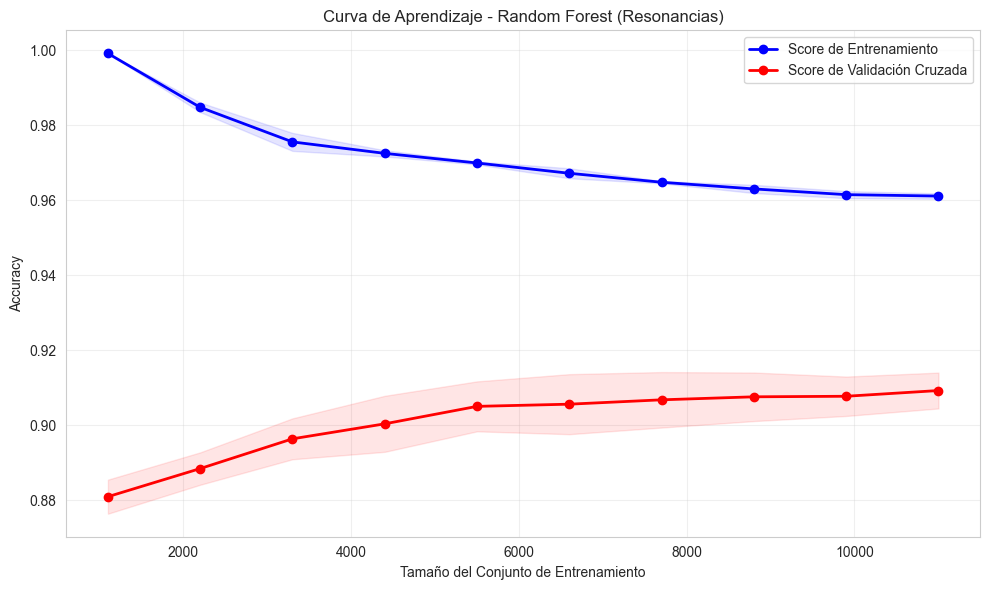

Score de entrenamiento final: 0.9611 (±0.0007)
Score de validación final: 0.9093 (±0.0048)
Gap (overfitting): 0.0518


In [78]:
# Curva de aprendizaje para Random Forest - Clasificación de Resonancias
print("\n=== CURVA DE APRENDIZAJE - RANDOM FOREST (RESONANCIAS) ===\n")

train_sizes_res, train_scores_res, test_scores_res = learning_curve(
    rf_resonancia, X_train_res_scaled, y_train_res,
    cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    random_state=42
)

# Calcular medias y desviaciones
train_scores_res_mean = np.mean(train_scores_res, axis=1)
train_scores_res_std = np.std(train_scores_res, axis=1)
test_scores_res_mean = np.mean(test_scores_res, axis=1)
test_scores_res_std = np.std(test_scores_res, axis=1)

# Visualizar
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes_res, train_scores_res_mean - train_scores_res_std,
                 train_scores_res_mean + train_scores_res_std, alpha=0.1, color="b")
plt.fill_between(train_sizes_res, test_scores_res_mean - test_scores_res_std,
                 test_scores_res_mean + test_scores_res_std, alpha=0.1, color="r")
plt.plot(train_sizes_res, train_scores_res_mean, 'o-', color="b", linewidth=2,
         label="Score de Entrenamiento")
plt.plot(train_sizes_res, test_scores_res_mean, 'o-', color="r", linewidth=2,
         label="Score de Validación Cruzada")

plt.xlabel("Tamaño del Conjunto de Entrenamiento")
plt.ylabel("Accuracy")
plt.title("Curva de Aprendizaje - Random Forest (Resonancias)")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Score de entrenamiento final: {train_scores_res_mean[-1]:.4f} (±{train_scores_res_std[-1]:.4f})")
print(f"Score de validación final: {test_scores_res_mean[-1]:.4f} (±{test_scores_res_std[-1]:.4f})")
print(f"Gap (overfitting): {(train_scores_res_mean[-1] - test_scores_res_mean[-1]):.4f}")

### 19.4 Gradient Boosting - Clasificación de Resonancias

In [68]:
# Entrenar Gradient Boosting para clasificación de resonancias
print("Entrenando Gradient Boosting para clasificación de resonancias...")
gb_resonancia = GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42)
gb_resonancia.fit(X_train_res_scaled, y_train_res)

# Predicciones
y_pred_gb_train = gb_resonancia.predict(X_train_res_scaled)
y_pred_gb_test = gb_resonancia.predict(X_test_res_scaled)

# Evaluación
accuracy_gb_train = accuracy_score(y_train_res, y_pred_gb_train)
accuracy_gb_test = accuracy_score(y_test_res, y_pred_gb_test)

print("\n=== RESULTADOS GRADIENT BOOSTING (RESONANCIAS) ===")
print(f"Accuracy Train: {accuracy_gb_train:.4f} ({accuracy_gb_train*100:.2f}%)")
print(f"Accuracy Test: {accuracy_gb_test:.4f} ({accuracy_gb_test*100:.2f}%)")
print("\n=== REPORTE DE CLASIFICACIÓN (Test) ===")
print(classification_report(y_test_res, y_pred_gb_test))

Entrenando Gradient Boosting para clasificación de resonancias...

=== RESULTADOS GRADIENT BOOSTING (RESONANCIAS) ===
Accuracy Train: 0.9873 (98.73%)
Accuracy Test: 0.9493 (94.93%)

=== REPORTE DE CLASIFICACIÓN (Test) ===
              precision    recall  f1-score   support

         J/ψ       0.91      0.98      0.95      2588
           Z       0.99      1.00      1.00      1399
           Υ       0.97      0.87      0.92      1908

    accuracy                           0.95      5895
   macro avg       0.96      0.95      0.95      5895
weighted avg       0.95      0.95      0.95      5895


=== RESULTADOS GRADIENT BOOSTING (RESONANCIAS) ===
Accuracy Train: 0.9873 (98.73%)
Accuracy Test: 0.9493 (94.93%)

=== REPORTE DE CLASIFICACIÓN (Test) ===
              precision    recall  f1-score   support

         J/ψ       0.91      0.98      0.95      2588
           Z       0.99      1.00      1.00      1399
           Υ       0.97      0.87      0.92      1908

    accuracy           

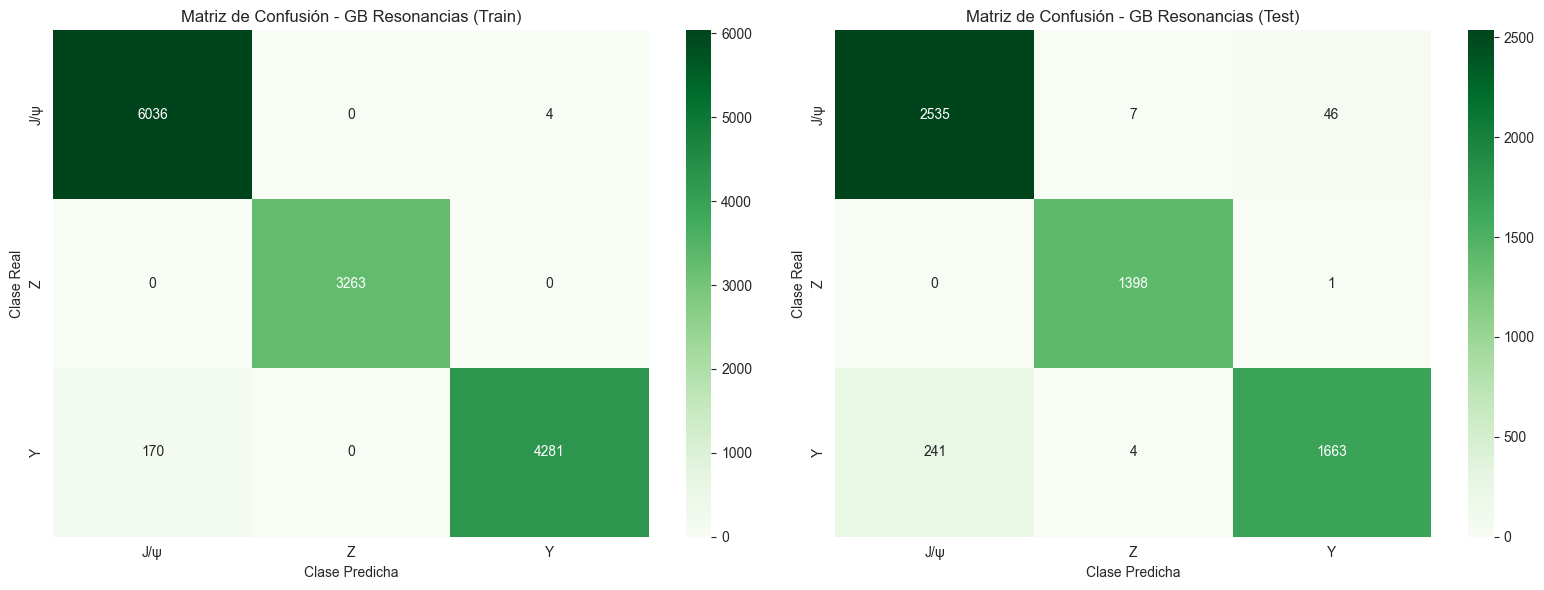

In [69]:
# Matrices de confusión - Gradient Boosting
cm_gb_train = confusion_matrix(y_train_res, y_pred_gb_train)
cm_gb_test = confusion_matrix(y_test_res, y_pred_gb_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train
sns.heatmap(cm_gb_train, annot=True, fmt='d', cmap='Greens',
            xticklabels=gb_resonancia.classes_,
            yticklabels=gb_resonancia.classes_,
            ax=axes[0])
axes[0].set_title('Matriz de Confusión - GB Resonancias (Train)')
axes[0].set_ylabel('Clase Real')
axes[0].set_xlabel('Clase Predicha')

# Test
sns.heatmap(cm_gb_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=gb_resonancia.classes_,
            yticklabels=gb_resonancia.classes_,
            ax=axes[1])
axes[1].set_title('Matriz de Confusión - GB Resonancias (Test)')
axes[1].set_ylabel('Clase Real')
axes[1].set_xlabel('Clase Predicha')

plt.tight_layout()
plt.show()

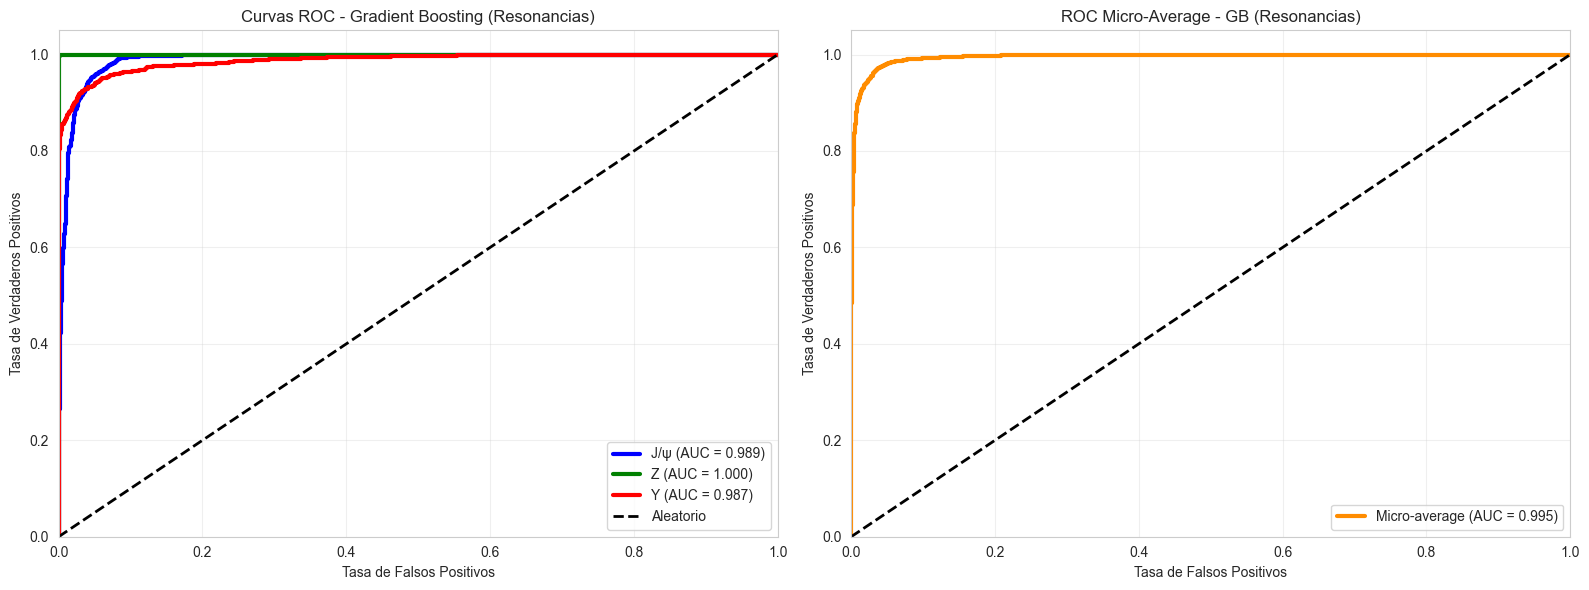


=== AUC SCORES - GRADIENT BOOSTING ===
J/ψ: 0.9887
Z: 1.0000
Υ: 0.9872
Micro-average: 0.9948


In [70]:
# Curvas ROC - Gradient Boosting
y_pred_proba_gb = gb_resonancia.predict_proba(X_test_res_scaled)

# Calcular ROC y AUC
fpr_gb_res = dict()
tpr_gb_res = dict()
roc_auc_gb_res = dict()

for i in range(n_classes_res):
    fpr_gb_res[i], tpr_gb_res[i], _ = roc_curve(y_test_res_bin[:, i], y_pred_proba_gb[:, i])
    roc_auc_gb_res[i] = auc(fpr_gb_res[i], tpr_gb_res[i])

# Micro-average
fpr_gb_res["micro"], tpr_gb_res["micro"], _ = roc_curve(y_test_res_bin.ravel(), y_pred_proba_gb.ravel())
roc_auc_gb_res["micro"] = auc(fpr_gb_res["micro"], tpr_gb_res["micro"])

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC por clase
colors = {'J/ψ': 'blue', 'Υ': 'red', 'Z': 'green'}
for i, resonancia in enumerate(classes_res):
    color = colors.get(resonancia, 'purple')
    axes[0].plot(fpr_gb_res[i], tpr_gb_res[i], color=color, lw=3,
                 label=f'{resonancia} (AUC = {roc_auc_gb_res[i]:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Aleatorio')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curvas ROC - Gradient Boosting (Resonancias)')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Micro-average
axes[1].plot(fpr_gb_res["micro"], tpr_gb_res["micro"], color='darkorange', lw=3,
             label=f'Micro-average (AUC = {roc_auc_gb_res["micro"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('ROC Micro-Average - GB (Resonancias)')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== AUC SCORES - GRADIENT BOOSTING ===")
for i, resonancia in enumerate(classes_res):
    print(f"{resonancia}: {roc_auc_gb_res[i]:.4f}")
print(f"Micro-average: {roc_auc_gb_res['micro']:.4f}")


=== CURVA DE APRENDIZAJE - GRADIENT BOOSTING (RESONANCIAS) ===



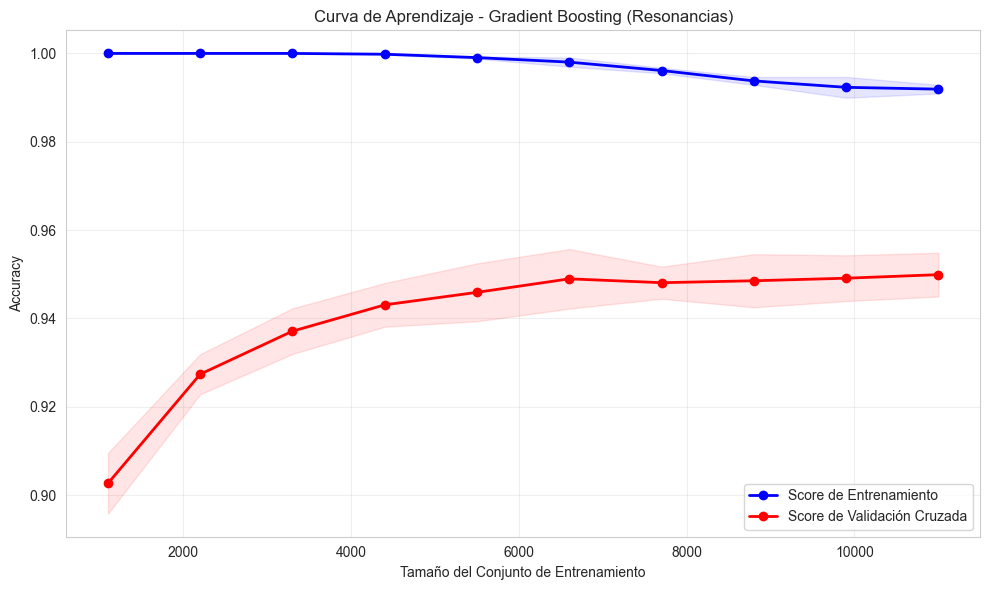

Score de entrenamiento final: 0.9919 (±0.0010)
Score de validación final: 0.9499 (±0.0050)
Gap (overfitting): 0.0420


In [76]:
# Curva de aprendizaje - Gradient Boosting
print("\n=== CURVA DE APRENDIZAJE - GRADIENT BOOSTING (RESONANCIAS) ===\n")

train_sizes_gb_res, train_scores_gb_res, test_scores_gb_res = learning_curve(
    gb_resonancia, X_train_res_scaled, y_train_res,
    cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    random_state=42
)

# Calcular medias y desviaciones
train_scores_gb_res_mean = np.mean(train_scores_gb_res, axis=1)
train_scores_gb_res_std = np.std(train_scores_gb_res, axis=1)
test_scores_gb_res_mean = np.mean(test_scores_gb_res, axis=1)
test_scores_gb_res_std = np.std(test_scores_gb_res, axis=1)

# Visualizar
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes_gb_res, train_scores_gb_res_mean - train_scores_gb_res_std,
                 train_scores_gb_res_mean + train_scores_gb_res_std, alpha=0.1, color="b")
plt.fill_between(train_sizes_gb_res, test_scores_gb_res_mean - test_scores_gb_res_std,
                 test_scores_gb_res_mean + test_scores_gb_res_std, alpha=0.1, color="r")
plt.plot(train_sizes_gb_res, train_scores_gb_res_mean, 'o-', color="b", linewidth=2,
         label="Score de Entrenamiento")
plt.plot(train_sizes_gb_res, test_scores_gb_res_mean, 'o-', color="r", linewidth=2,
         label="Score de Validación Cruzada")

plt.xlabel("Tamaño del Conjunto de Entrenamiento")
plt.ylabel("Accuracy")
plt.title("Curva de Aprendizaje - Gradient Boosting (Resonancias)")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Score de entrenamiento final: {train_scores_gb_res_mean[-1]:.4f} (±{train_scores_gb_res_std[-1]:.4f})")
print(f"Score de validación final: {test_scores_gb_res_mean[-1]:.4f} (±{test_scores_gb_res_std[-1]:.4f})")
print(f"Gap (overfitting): {(train_scores_gb_res_mean[-1] - test_scores_gb_res_mean[-1]):.4f}")

### 19.5 SVM - Clasificación de Resonancias

In [72]:
# Entrenar SVM para clasificación de resonancias
print("Entrenando SVM para clasificación de resonancias (esto puede tardar)...")
svm_resonancia = SVC(kernel='rbf', probability=True, random_state=42)
svm_resonancia.fit(X_train_res_scaled, y_train_res)

# Predicciones
y_pred_svm_train = svm_resonancia.predict(X_train_res_scaled)
y_pred_svm_test = svm_resonancia.predict(X_test_res_scaled)

# Evaluación
accuracy_svm_train = accuracy_score(y_train_res, y_pred_svm_train)
accuracy_svm_test = accuracy_score(y_test_res, y_pred_svm_test)

print("\n=== RESULTADOS SVM (RESONANCIAS) ===")
print(f"Accuracy Train: {accuracy_svm_train:.4f} ({accuracy_svm_train*100:.2f}%)")
print(f"Accuracy Test: {accuracy_svm_test:.4f} ({accuracy_svm_test*100:.2f}%)")
print("\n=== REPORTE DE CLASIFICACIÓN (Test) ===")
print(classification_report(y_test_res, y_pred_svm_test))

Entrenando SVM para clasificación de resonancias (esto puede tardar)...

=== RESULTADOS SVM (RESONANCIAS) ===
Accuracy Train: 0.9273 (92.73%)
Accuracy Test: 0.9226 (92.26%)

=== REPORTE DE CLASIFICACIÓN (Test) ===
              precision    recall  f1-score   support

         J/ψ       0.89      0.95      0.91      2588
           Z       1.00      1.00      1.00      1399
           Υ       0.92      0.83      0.88      1908

    accuracy                           0.92      5895
   macro avg       0.93      0.93      0.93      5895
weighted avg       0.92      0.92      0.92      5895



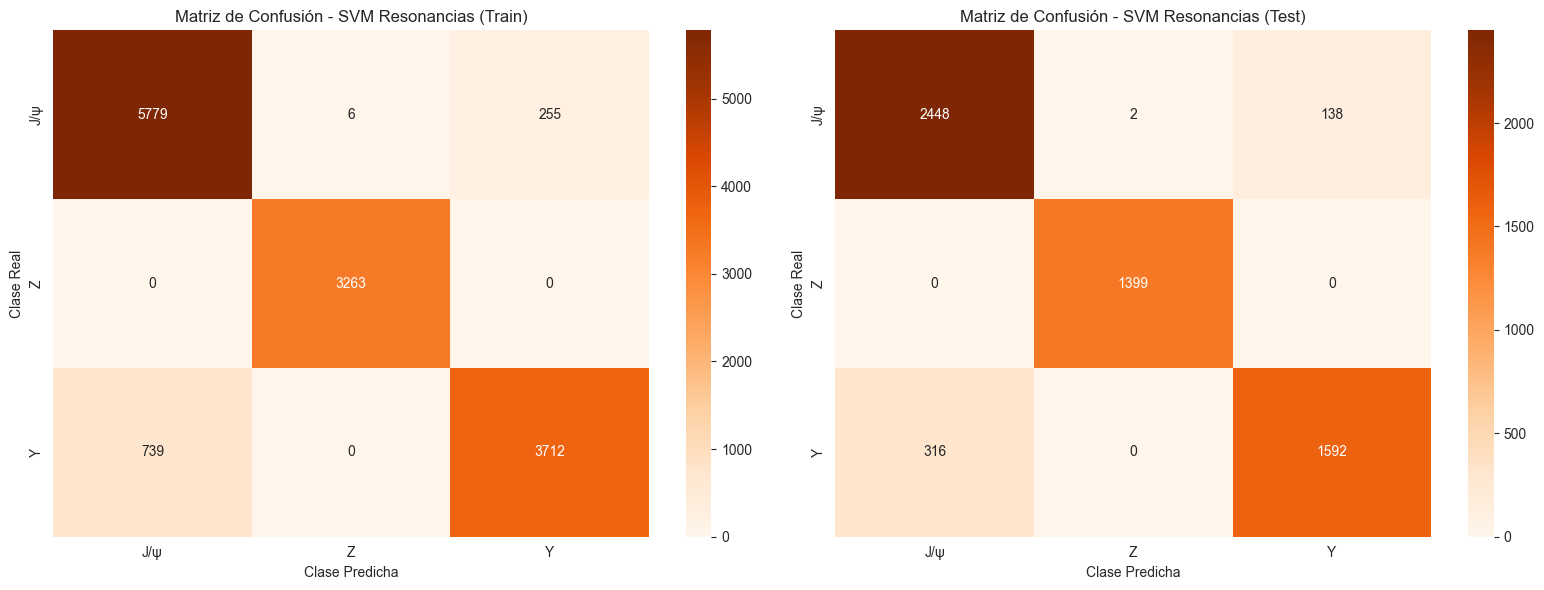

In [73]:
# Matrices de confusión - SVM
cm_svm_train = confusion_matrix(y_train_res, y_pred_svm_train)
cm_svm_test = confusion_matrix(y_test_res, y_pred_svm_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train
sns.heatmap(cm_svm_train, annot=True, fmt='d', cmap='Oranges',
            xticklabels=svm_resonancia.classes_,
            yticklabels=svm_resonancia.classes_,
            ax=axes[0])
axes[0].set_title('Matriz de Confusión - SVM Resonancias (Train)')
axes[0].set_ylabel('Clase Real')
axes[0].set_xlabel('Clase Predicha')

# Test
sns.heatmap(cm_svm_test, annot=True, fmt='d', cmap='Oranges',
            xticklabels=svm_resonancia.classes_,
            yticklabels=svm_resonancia.classes_,
            ax=axes[1])
axes[1].set_title('Matriz de Confusión - SVM Resonancias (Test)')
axes[1].set_ylabel('Clase Real')
axes[1].set_xlabel('Clase Predicha')

plt.tight_layout()
plt.show()

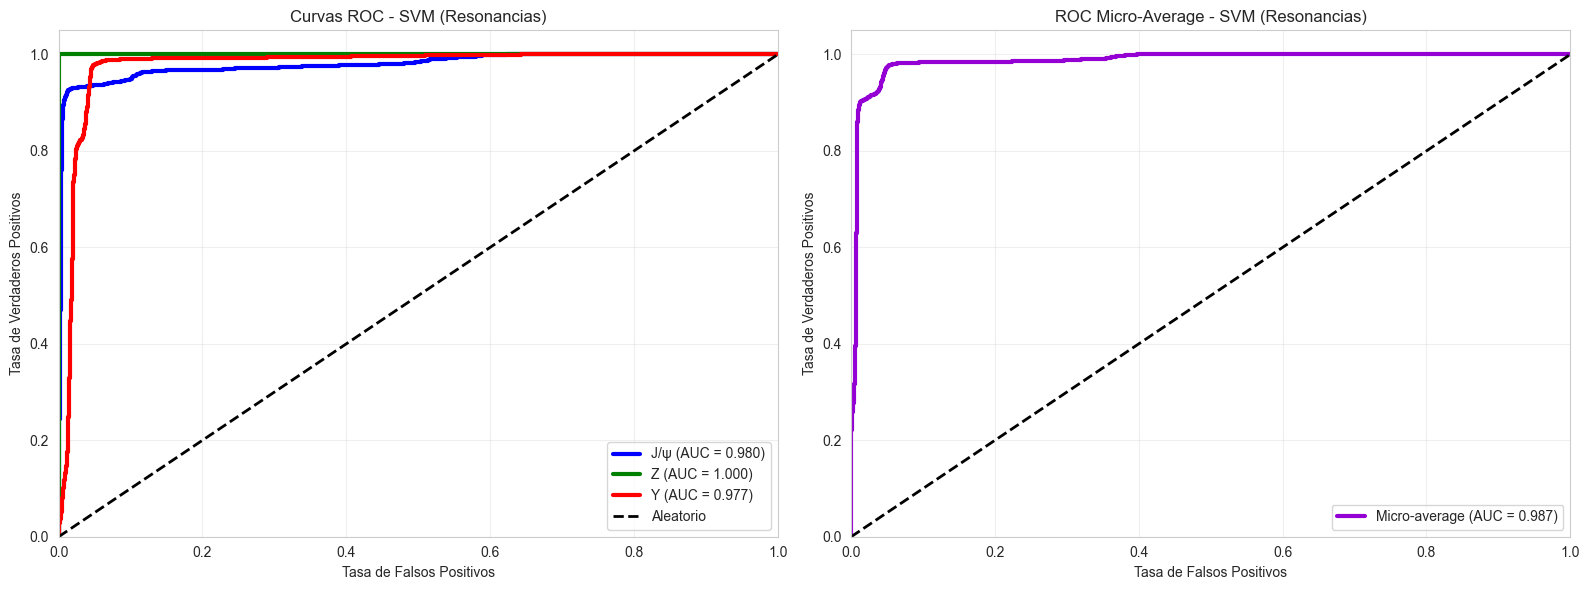


=== AUC SCORES - SVM ===
J/ψ: 0.9796
Z: 1.0000
Υ: 0.9766
Micro-average: 0.9867


In [74]:
# Curvas ROC - SVM
y_pred_proba_svm = svm_resonancia.predict_proba(X_test_res_scaled)

# Calcular ROC y AUC
fpr_svm_res = dict()
tpr_svm_res = dict()
roc_auc_svm_res = dict()

for i in range(n_classes_res):
    fpr_svm_res[i], tpr_svm_res[i], _ = roc_curve(y_test_res_bin[:, i], y_pred_proba_svm[:, i])
    roc_auc_svm_res[i] = auc(fpr_svm_res[i], tpr_svm_res[i])

# Micro-average
fpr_svm_res["micro"], tpr_svm_res["micro"], _ = roc_curve(y_test_res_bin.ravel(), y_pred_proba_svm.ravel())
roc_auc_svm_res["micro"] = auc(fpr_svm_res["micro"], tpr_svm_res["micro"])

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC por clase
colors = {'J/ψ': 'blue', 'Υ': 'red', 'Z': 'green'}
for i, resonancia in enumerate(classes_res):
    color = colors.get(resonancia, 'purple')
    axes[0].plot(fpr_svm_res[i], tpr_svm_res[i], color=color, lw=3,
                 label=f'{resonancia} (AUC = {roc_auc_svm_res[i]:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Aleatorio')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curvas ROC - SVM (Resonancias)')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Micro-average
axes[1].plot(fpr_svm_res["micro"], tpr_svm_res["micro"], color='darkviolet', lw=3,
             label=f'Micro-average (AUC = {roc_auc_svm_res["micro"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('ROC Micro-Average - SVM (Resonancias)')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== AUC SCORES - SVM ===")
for i, resonancia in enumerate(classes_res):
    print(f"{resonancia}: {roc_auc_svm_res[i]:.4f}")
print(f"Micro-average: {roc_auc_svm_res['micro']:.4f}")


=== CURVA DE APRENDIZAJE - SVM (RESONANCIAS) ===



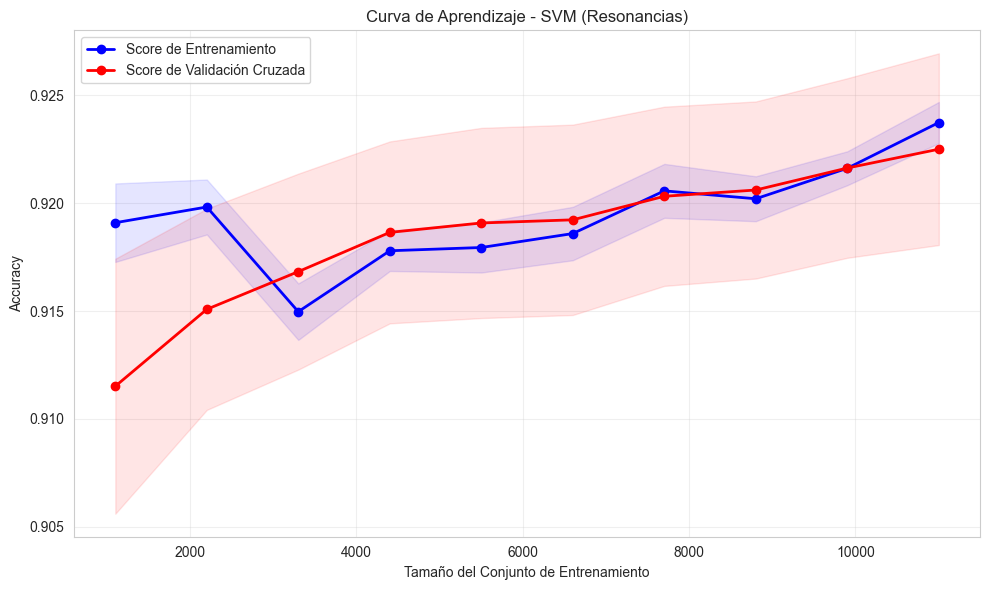

Score de entrenamiento final: 0.9237 (±0.0010)
Score de validación final: 0.9225 (±0.0044)
Gap (overfitting): 0.0012


In [75]:
# Curva de aprendizaje - SVM
print("\n=== CURVA DE APRENDIZAJE - SVM (RESONANCIAS) ===\n")

train_sizes_svm_res, train_scores_svm_res, test_scores_svm_res = learning_curve(
    svm_resonancia, X_train_res_scaled, y_train_res,
    cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    random_state=42
)

# Calcular medias y desviaciones
train_scores_svm_res_mean = np.mean(train_scores_svm_res, axis=1)
train_scores_svm_res_std = np.std(train_scores_svm_res, axis=1)
test_scores_svm_res_mean = np.mean(test_scores_svm_res, axis=1)
test_scores_svm_res_std = np.std(test_scores_svm_res, axis=1)

# Visualizar
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes_svm_res, train_scores_svm_res_mean - train_scores_svm_res_std,
                 train_scores_svm_res_mean + train_scores_svm_res_std, alpha=0.1, color="b")
plt.fill_between(train_sizes_svm_res, test_scores_svm_res_mean - test_scores_svm_res_std,
                 test_scores_svm_res_mean + test_scores_svm_res_std, alpha=0.1, color="r")
plt.plot(train_sizes_svm_res, train_scores_svm_res_mean, 'o-', color="b", linewidth=2,
         label="Score de Entrenamiento")
plt.plot(train_sizes_svm_res, test_scores_svm_res_mean, 'o-', color="r", linewidth=2,
         label="Score de Validación Cruzada")

plt.xlabel("Tamaño del Conjunto de Entrenamiento")
plt.ylabel("Accuracy")
plt.title("Curva de Aprendizaje - SVM (Resonancias)")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Score de entrenamiento final: {train_scores_svm_res_mean[-1]:.4f} (±{train_scores_svm_res_std[-1]:.4f})")
print(f"Score de validación final: {test_scores_svm_res_mean[-1]:.4f} (±{test_scores_svm_res_std[-1]:.4f})")
print(f"Gap (overfitting): {(train_scores_svm_res_mean[-1] - test_scores_svm_res_mean[-1]):.4f}")

### 19.6 Comparación de Modelos de Clasificación

=== COMPARACIÓN DE MODELOS - CLASIFICACIÓN DE RESONANCIAS ===
           Modelo  Accuracy Train  Accuracy Test  AUC Micro-Average
Gradient Boosting        0.987349       0.949279           0.994801
              SVM        0.927294       0.922646           0.986712
    Random Forest        0.959285       0.914504           0.988018


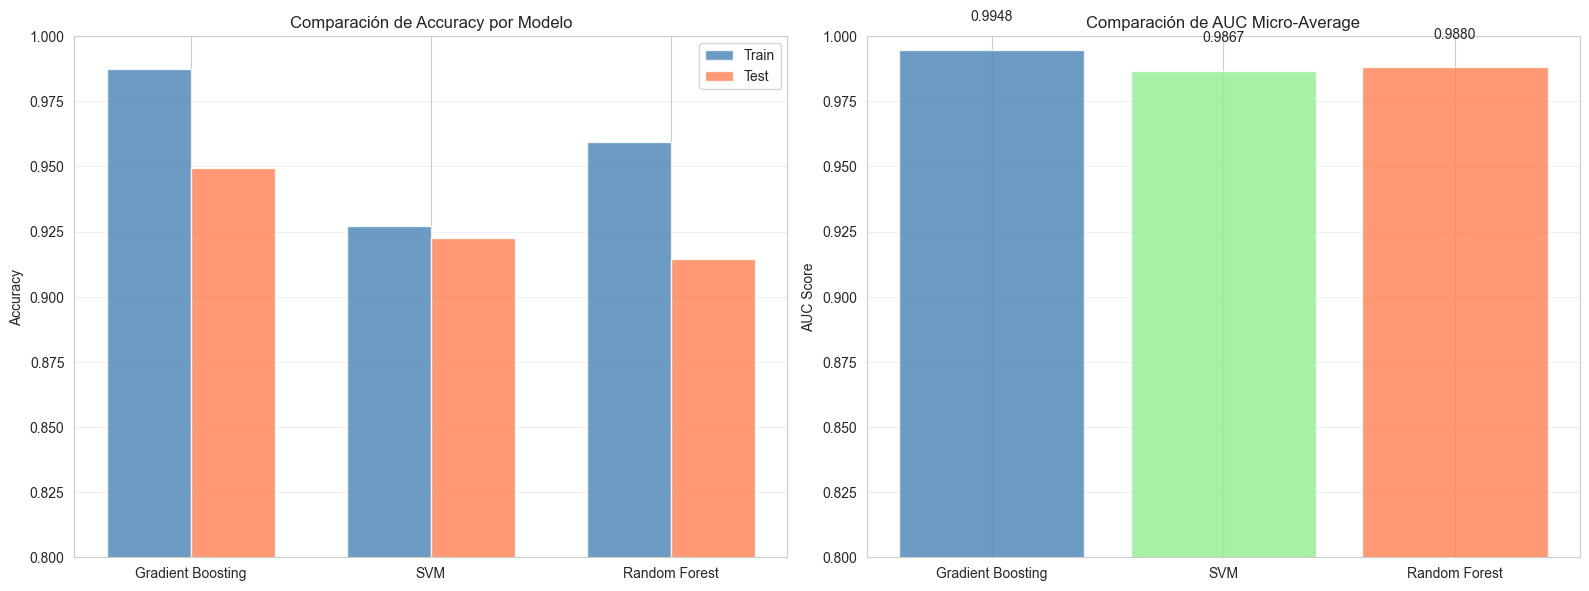

In [77]:
# Comparación de rendimiento de los tres modelos
comparacion_resonancias = pd.DataFrame({
    'Modelo': ['Random Forest', 'Gradient Boosting', 'SVM'],
    'Accuracy Train': [accuracy_res_train, accuracy_gb_train, accuracy_svm_train],
    'Accuracy Test': [accuracy_res_test, accuracy_gb_test, accuracy_svm_test],
    'AUC Micro-Average': [roc_auc_res['micro'], roc_auc_gb_res['micro'], roc_auc_svm_res['micro']]
}).sort_values('Accuracy Test', ascending=False)

print("=== COMPARACIÓN DE MODELOS - CLASIFICACIÓN DE RESONANCIAS ===")
print(comparacion_resonancias.to_string(index=False))

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
x = np.arange(len(comparacion_resonancias))
width = 0.35

axes[0].bar(x - width/2, comparacion_resonancias['Accuracy Train'], width, 
            label='Train', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, comparacion_resonancias['Accuracy Test'], width,
            label='Test', color='coral', alpha=0.8)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Comparación de Accuracy por Modelo')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparacion_resonancias['Modelo'])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0.8, 1.0])

# AUC
axes[1].bar(comparacion_resonancias['Modelo'], comparacion_resonancias['AUC Micro-Average'],
            color=['steelblue', 'lightgreen', 'coral'], alpha=0.8)
axes[1].set_ylabel('AUC Score')
axes[1].set_title('Comparación de AUC Micro-Average')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim([0.8, 1.0])

# Añadir valores sobre las barras
for i, v in enumerate(comparacion_resonancias['AUC Micro-Average']):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()